<a href="https://colab.research.google.com/github/Pauline-Zeestraten/E-portfolio-DSBA-program/blob/main/3_Recell_Startup_Notebook_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervised Learning - Foundations Project: ReCell

## Problem Statement

### Business Context

Buying and selling used phones and tablets used to be something that happened on a handful of online marketplace sites. But the used and refurbished device market has grown considerably over the past decade, and a new IDC (International Data Corporation) forecast predicts that the used phone market would be worth \\$52.7bn by 2023 with a compound annual growth rate (CAGR) of 13.6% from 2018 to 2023. This growth can be attributed to an uptick in demand for used phones and tablets that offer considerable savings compared with new models.

Refurbished and used devices continue to provide cost-effective alternatives to both consumers and businesses that are looking to save money when purchasing one. There are plenty of other benefits associated with the used device market. Used and refurbished devices can be sold with warranties and can also be insured with proof of purchase. Third-party vendors/platforms, such as Verizon, Amazon, etc., provide attractive offers to customers for refurbished devices. Maximizing the longevity of devices through second-hand trade also reduces their environmental impact and helps in recycling and reducing waste. The impact of the COVID-19 outbreak may further boost this segment as consumers cut back on discretionary spending and buy phones and tablets only for immediate needs.


### Objective

The rising potential of this comparatively under-the-radar market fuels the need for an ML-based solution to develop a dynamic pricing strategy for used and refurbished devices. ReCell, a startup aiming to tap the potential in this market, has hired you as a data scientist. They want you to analyze the data provided and build a linear regression model to predict the price of a used phone/tablet and identify factors that significantly influence it.


### Data Description

The data contains the different attributes of used/refurbished phones and tablets. The data was collected in the year 2021. The detailed data dictionary is given below.


- brand_name: Name of manufacturing brand
- os: OS on which the device runs
- screen_size: Size of the screen in cm
- 4g: Whether 4G is available or not
- 5g: Whether 5G is available or not
- main_camera_mp: Resolution of the rear camera in megapixels
- selfie_camera_mp: Resolution of the front camera in megapixels
- int_memory: Amount of internal memory (ROM) in GB
- ram: Amount of RAM in GB
- battery: Energy capacity of the device battery in mAh
- weight: Weight of the device in grams
- release_year: Year when the device model was released
- days_used: Number of days the used/refurbished device has been used
- normalized_new_price: Normalized price of a new device of the same model in euros
- normalized_used_price: Normalized price of the used/refurbished device in euros

## Importing necessary libraries

In [5]:
# this will help in making the Python code more structured automatically (good coding practice)


# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# split the data into train and test
from sklearn.model_selection import train_test_split

# to build linear regression_model
from sklearn.linear_model import LinearRegression

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# to build linear regression_model using statsmodels
import statsmodels.api as sm

# to compute VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Loading the dataset

In [7]:
# Load the data:
used_device_df = pd.read_csv('/content/drive/MyDrive/DSBA program/3. Supervised Learning - Foundations/used_device_data.csv')

In [8]:
# Copy data to another variable to avoid any changes to original data:
data = used_device_df.copy()

In [9]:
# Observe the first few rows of the dataset:
data.head()

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837


## Data Overview

- Observations
- Sanity checks

In [10]:
# Check size of dataset:
data.shape

(3454, 15)

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand_name             3454 non-null   object 
 1   os                     3454 non-null   object 
 2   screen_size            3454 non-null   float64
 3   4g                     3454 non-null   object 
 4   5g                     3454 non-null   object 
 5   main_camera_mp         3275 non-null   float64
 6   selfie_camera_mp       3452 non-null   float64
 7   int_memory             3450 non-null   float64
 8   ram                    3450 non-null   float64
 9   battery                3448 non-null   float64
 10  weight                 3447 non-null   float64
 11  release_year           3454 non-null   int64  
 12  days_used              3454 non-null   int64  
 13  normalized_used_price  3454 non-null   float64
 14  normalized_new_price   3454 non-null   float64
dtypes: f

Observation:  
* 4 columns with string datatype (['brand_name'], ['os'], ['4g'], ['5g']), and 11 columns with numerical datatype;
* There are missing values in columns ['main_camera_mp'], ['selfie_camera_mp'],['int_memory'], ['ram'], ['battery'], ['weight']


In [12]:
# Check statistical summary of numerical columns:
data.describe()

,screen_size,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
count,3454.000000,3275.000000,3452.000000,3450.000000,3450.000000,3448.000000,3447.000000,3454.000000,3454.000000,3454.000000,3454.000000
mean,13.713115,9.460208,6.554229,54.573099,4.036122,3133.402697,182.751871,2015.965258,674.869716,4.364712,5.233107
std,3.805280,4.815461,6.970372,84.972371,1.365105,1299.682844,88.413228,2.298455,248.580166,0.588914,0.683637
min,5.080000,0.080000,0.000000,0.010000,0.020000,500.000000,69.000000,2013.000000,91.000000,1.536867,2.901422
25%,12.700000,5.000000,2.000000,16.000000,4.000000,2100.000000,142.000000,2014.000000,533.500000,4.033931,4.790342
50%,12.830000,8.000000,5.000000,32.000000,4.000000,3000.000000,160.000000,2015.500000,690.500000,4.405133,5.245892
75%,15.340000,13.000000,8.000000,64.000000,4.000000,4000.000000,185.000000,2018.000000,868.750000,4.755700,5.673718
max,30.710000,48.000000,32.000000,1024.000000,12.000000,9720.000000,855.000000,2020.000000,1094.000000,6.619433,7.847841


## Data Preprocessing

- Missing value treatment
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [13]:
# Check for duplicate values:
data.duplicated().sum()

np.int64(0)

There are no duplicate values observed.

##Missing Value Imputation:
* We will impute the missing values in the data by the column medians grouped by 'release_year' and 'brand_name'.

We decide to impute as opposed to drop the missing values (because missing values in this case are not errors that can't be corrected): Using central tendency measures (mean, median, mode) of a column grouped by categories of a categorical column. Preferred for cases where the data under similar categories of a categorical column are likely to have similar properties.

In [14]:
# Check for missing values:
data.isnull().sum()

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,179
selfie_camera_mp,2
int_memory,4
ram,4
battery,6


- We will impute the missing values in the data by the column medians grouped by `release_year` and `brand_name`.

In [15]:
# Impute missing values in column ['main_camera_mp'] with the median of the column, grouped by 'release_year' and 'brand_name':
data['main_camera_mp'] = data['main_camera_mp'].fillna(value = data.groupby(['release_year', 'brand_name'])['main_camera_mp'].transform('median'))
data['main_camera_mp'].isnull().sum()


np.int64(179)

Still all missing values showing in this column.  Let's groupby ['brand_name'] only instead.

In [16]:
data['main_camera_mp'] = data['main_camera_mp'].fillna(value = data.groupby(['brand_name'])['main_camera_mp'].transform('median'))
data['main_camera_mp'].isnull().sum()

np.int64(10)

10 missing values still showing. Let's groupby ['release_year'] only instead.

In [17]:
data['main_camera_mp'] = data['main_camera_mp'].fillna(value = data.groupby(['release_year'])['main_camera_mp'].transform('median'))
data['main_camera_mp'].isnull().sum()

np.int64(0)

In [18]:
# Impute missing values for ['selfie_camera_mp'] with the median of the column grouped by 'release year' and 'brand_name':
data['selfie_camera_mp'] = data['selfie_camera_mp'].fillna(value = data.groupby(['release_year', 'brand_name'])['selfie_camera_mp'].transform('median'))
data['selfie_camera_mp']
data['selfie_camera_mp'].isnull().sum()

np.int64(2)

In [19]:
# Missing values still showing (only 2).  Let's groupby Brand Name only and transform the median:
data['selfie_camera_mp'] = data['selfie_camera_mp'].fillna(value = data.groupby(['brand_name'])['selfie_camera_mp'].transform('median'))
data['selfie_camera_mp'].isnull().sum()

np.int64(0)

In [20]:
# Impute missing values for ['int_memory'] with the median of the column grouped by 'release year' and 'brand_name':
data['int_memory'] = data['int_memory'].fillna(value = data.groupby(['release_year', 'brand_name'])['int_memory'].transform('median'))
data['int_memory']
data['int_memory'].isnull().sum()

np.int64(0)

In [21]:
# Impute missing values for ['ram'] with the median of the column grouped by 'release_year' and 'brand_name':
data['ram'] = data['ram'].fillna(value = data.groupby(['release_year', 'brand_name'])['ram'].transform('median'))
data['ram'].isnull().sum()

np.int64(0)

In [22]:
# Impute missing values for ['battery'] with the median of the column grouped by 'release_year' and 'brand_name':
data['battery'] = data['battery'].fillna(value = data.groupby(['brand_name'])['battery'].transform('median'))
data['battery'].isnull().sum()

np.int64(0)

In [23]:
# Impute missing values for ['weight'] with the median of the column grouped by 'brand_name':
data['weight'] = data['weight'].fillna(value = data.groupby(['brand_name'])['weight'].transform('median'))
data['weight'].isnull().sum()

np.int64(0)

In [24]:
data.isnull().sum()

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,0
selfie_camera_mp,0
int_memory,0
ram,0
battery,0


No more missing values.

### Feature Engineering



- Let's create a new column `years_since_release` from the `release_year` column.
- We will consider the year of data collection, 2021, as the baseline.
- We will drop the `release_year` column.

In [25]:
# Let's create a new column ['years_since_release'] from ['release_year'] column.  We will consider the year of data collection, 2021, as the baseline:
data['years_since_release'] = 2021 - data['release_year']
data['years_since_release']

,years_since_release
0,1
1,1
2,1
3,1
4,1
...,...
3449,2
3450,3
3451,1
3452,1


In [26]:
# Let's drop column 'release year' without creating a new dataframe.  Existing dataframe will be modified in place.
data.drop('release_year', axis=1, inplace=True) # add axis=1 is necessary so Pandas knows to look for this label under columns, and not rows (axis=0)



In [27]:
data['years_since_release'].describe()

,years_since_release
count,3454.000000
mean,5.034742
std,2.298455
min,1.000000
25%,3.000000
50%,5.500000
75%,7.000000
max,8.000000


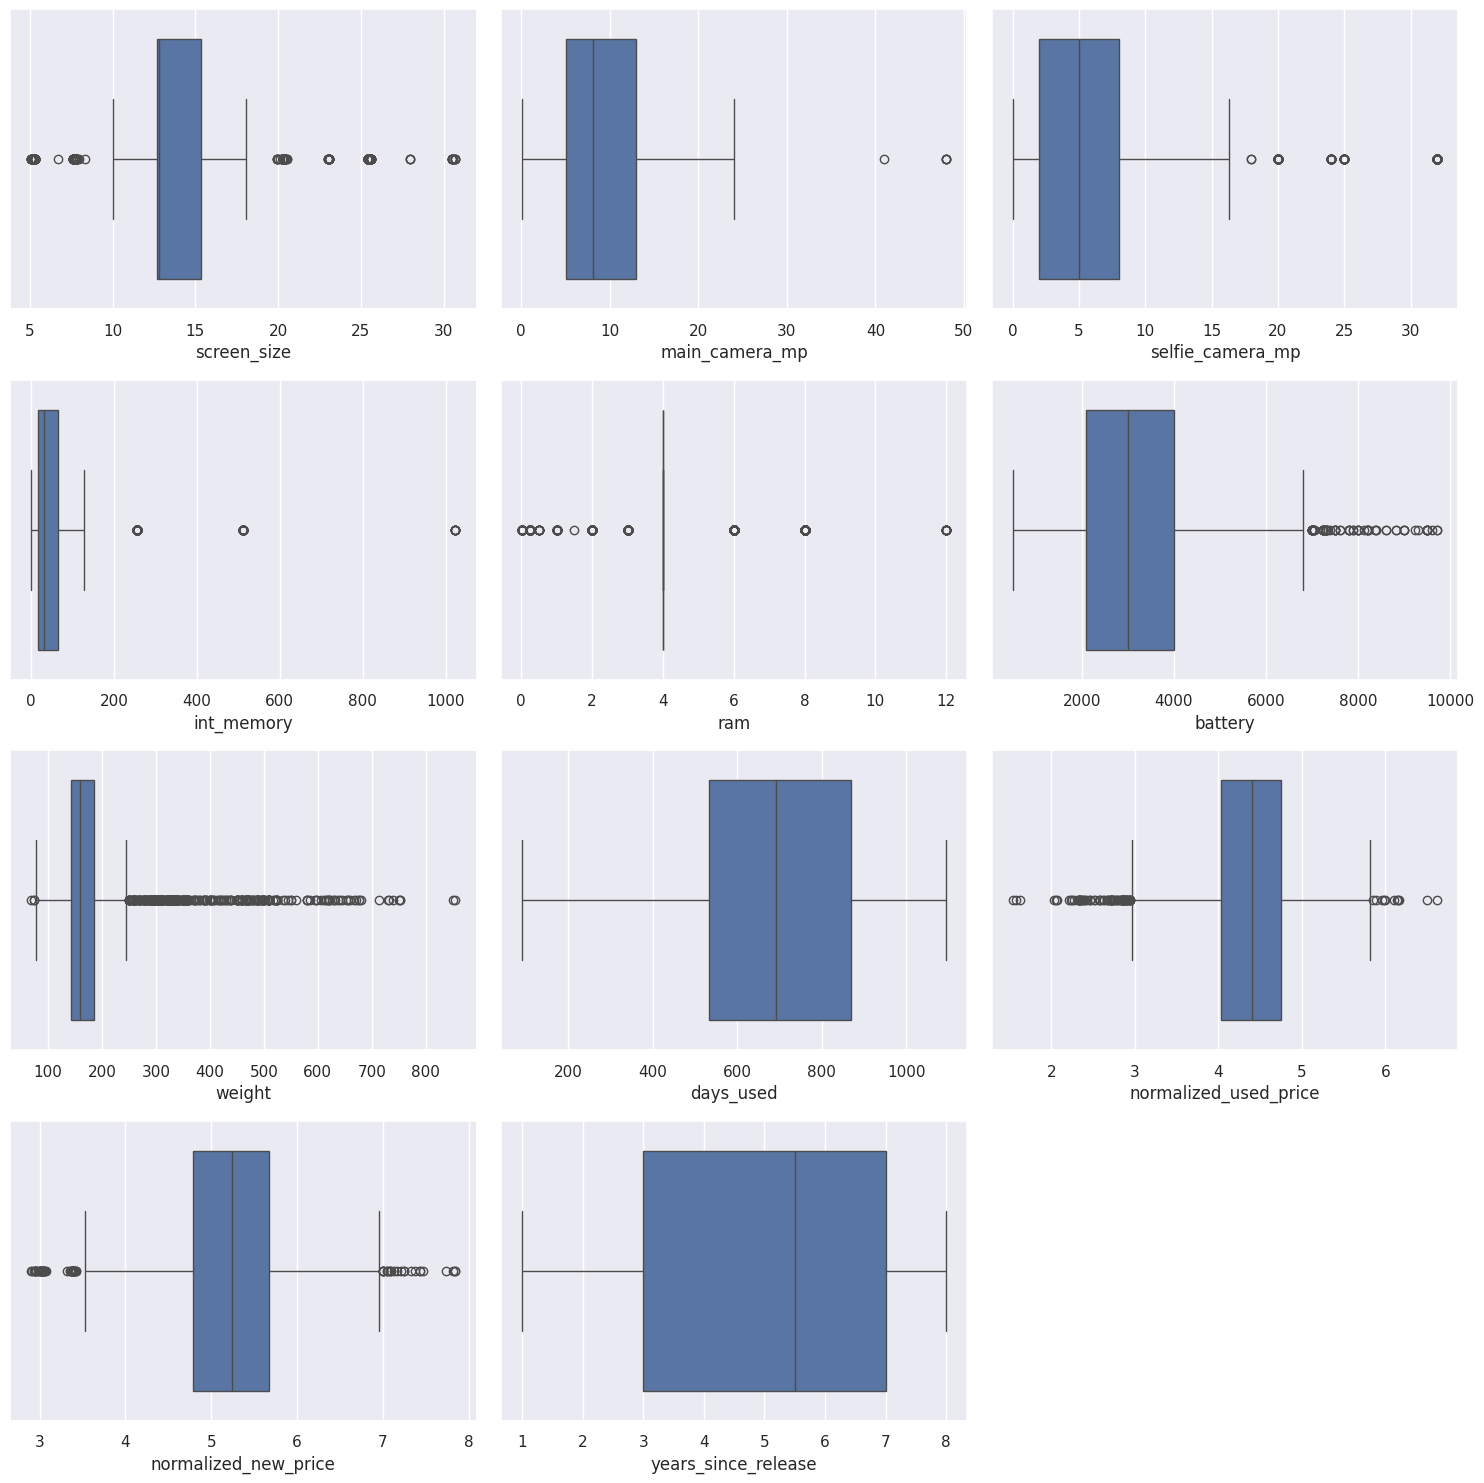

In [28]:
# Outlier detection using a boxplot:
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 15))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(data, x=variable)
    plt.tight_layout()

plt.show()

Observation:

There are outliers in the data, but we will not treat them as they are proper values, and they might depend on media type (phone or tablet).

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What does the distribution of normalized used device prices look like?
2. What percentage of the used device market is dominated by Android devices?
3. The amount of RAM is important for the smooth functioning of a device. How does the amount of RAM vary with the brand?
4. A large battery often increases a device's weight, making it feel uncomfortable in the hands. How does the weight vary for phones and tablets offering large batteries (more than 4500 mAh)?
5. Bigger screens are desirable for entertainment purposes as they offer a better viewing experience. How many phones and tablets are available across different brands with a screen size larger than 6 inches?
6. A lot of devices nowadays offer great selfie cameras, allowing us to capture our favorite moments with loved ones. What is the distribution of devices offering greater than 8MP selfie cameras across brands?
7. Which attributes are highly correlated with the normalized price of a used device?

It is a good idea to explore the data once again after manipulating it:

In [29]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
screen_size,3454.0,13.713115,3.805280,5.080000,12.700000,12.830000,15.340000,30.710000
main_camera_mp,3454.0,9.632073,4.752105,0.080000,5.000000,8.100000,13.000000,48.000000
selfie_camera_mp,3454.0,6.555067,6.968440,0.000000,2.000000,5.000000,8.000000,32.000000
int_memory,3454.0,54.528474,84.934991,0.010000,16.000000,32.000000,64.000000,1024.000000
ram,3454.0,4.032620,1.368598,0.020000,4.000000,4.000000,4.000000,12.000000
battery,3454.0,3132.577446,1298.884193,500.000000,2100.000000,3000.000000,4000.000000,9720.000000
weight,3454.0,182.636856,88.360445,69.000000,142.000000,160.000000,185.000000,855.000000
days_used,3454.0,674.869716,248.580166,91.000000,533.500000,690.500000,868.750000,1094.000000
normalized_used_price,3454.0,4.364712,0.588914,1.536867,4.033931,4.405133,4.755700,6.619433
normalized_new_price,3454.0,5.233107,0.683637,2.901422,4.790342,5.245892,5.673718,7.847841


We observe that the mean for category "main_camera_mp" has increased from 9.4 to 9.6 after treating 179 missing values (out of 3454 values).

##Univariate Analysis:

In [30]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [31]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        legend= False,
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

**Normalized Used Price**

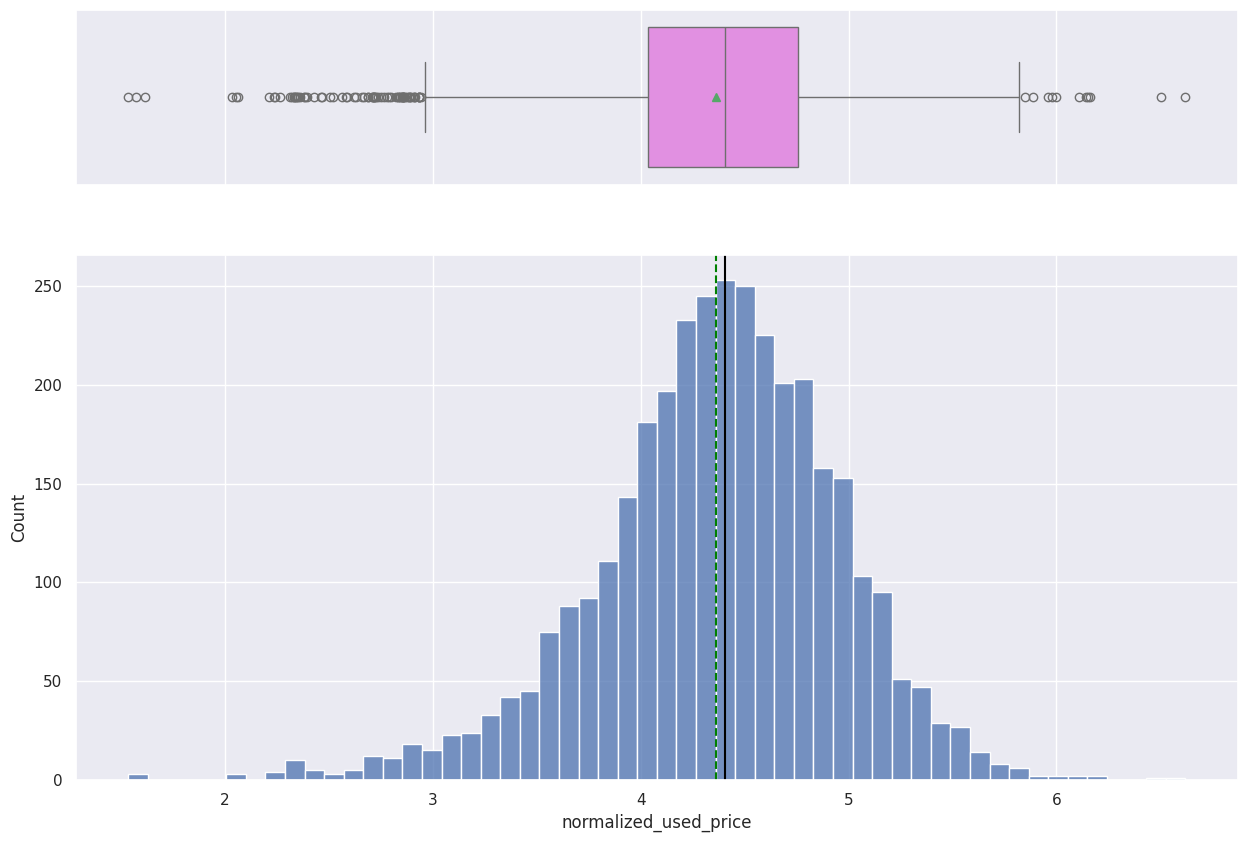

In [32]:
histogram_boxplot(data, "normalized_used_price")


**Normalized New Price**

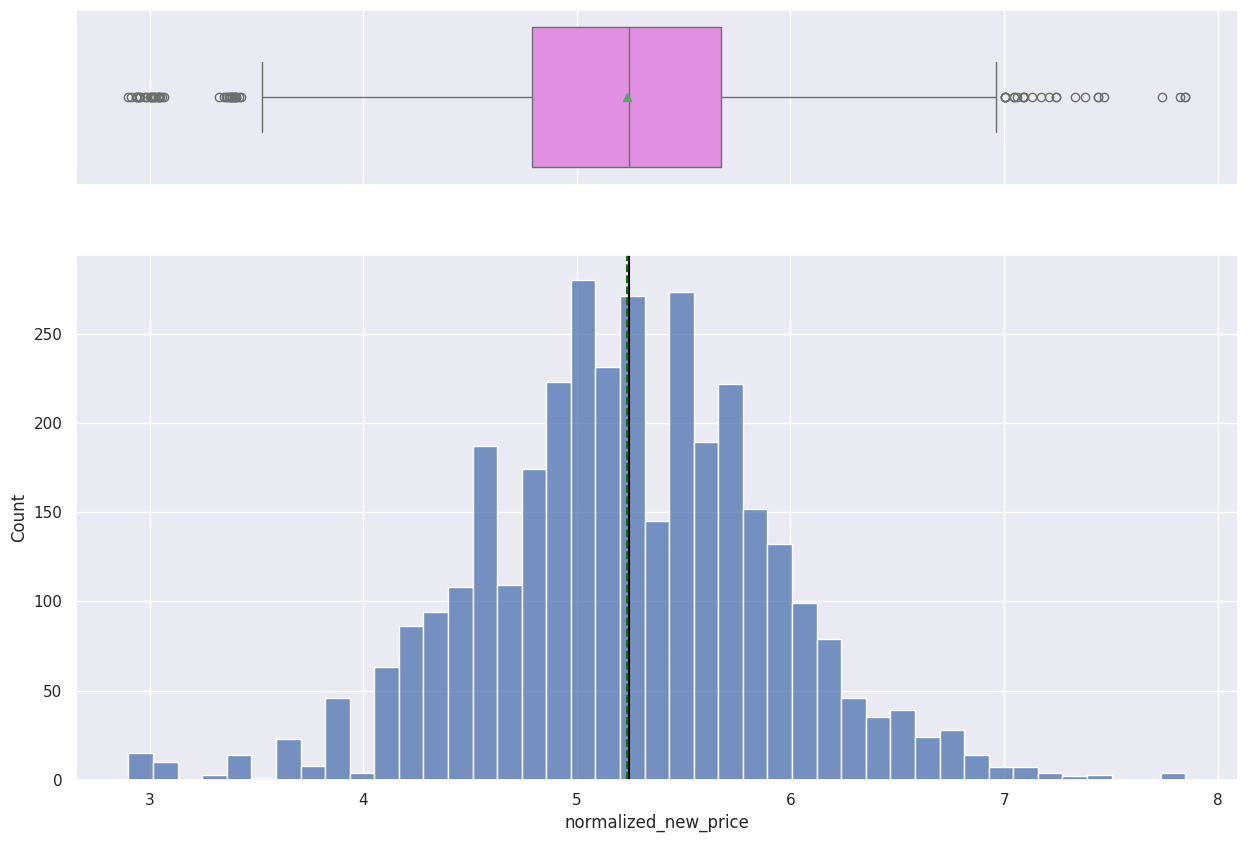

In [33]:
histogram_boxplot(data, "normalized_new_price")

**Screen Size**

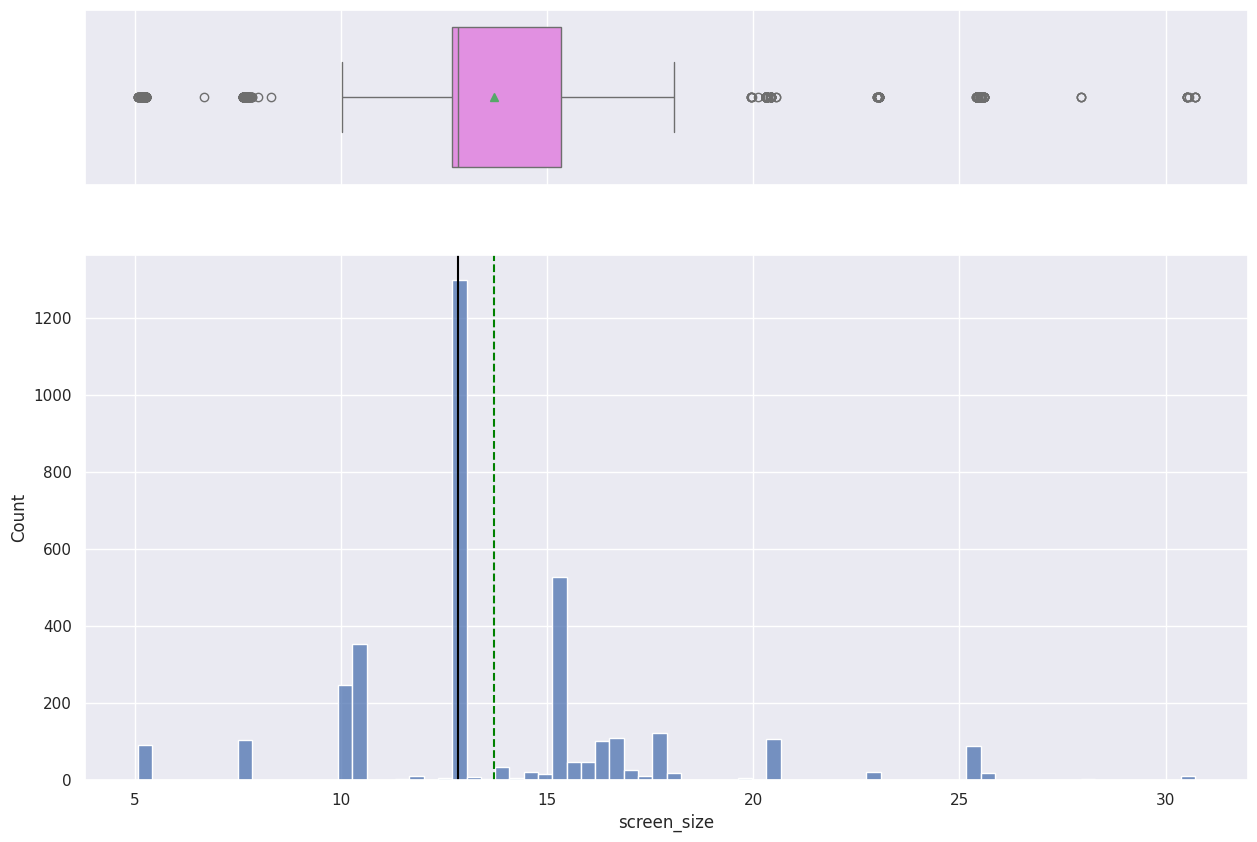

In [34]:
histogram_boxplot(data, "screen_size")

**Main Camera Mega Pixels **

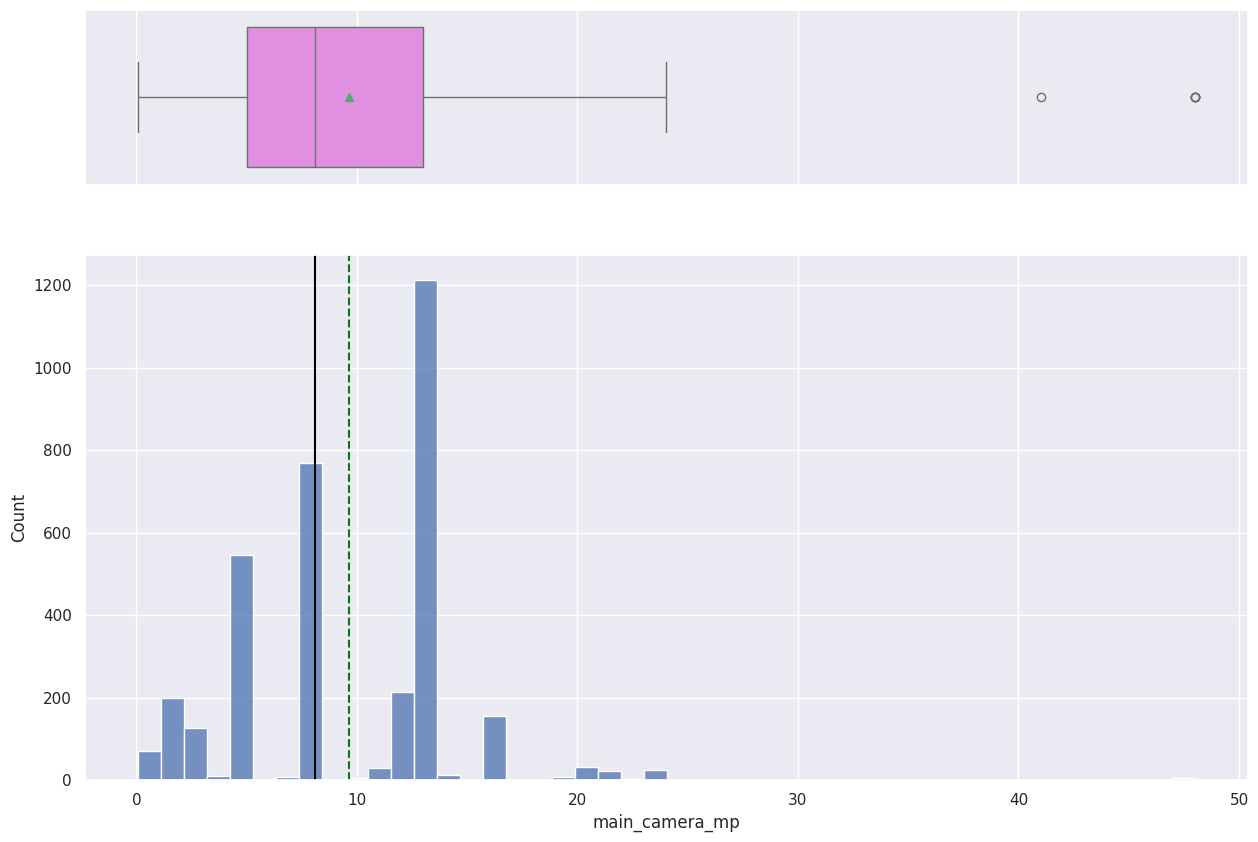

In [35]:
histogram_boxplot(data, "main_camera_mp")

**Selfie Camera Mega Pixels**

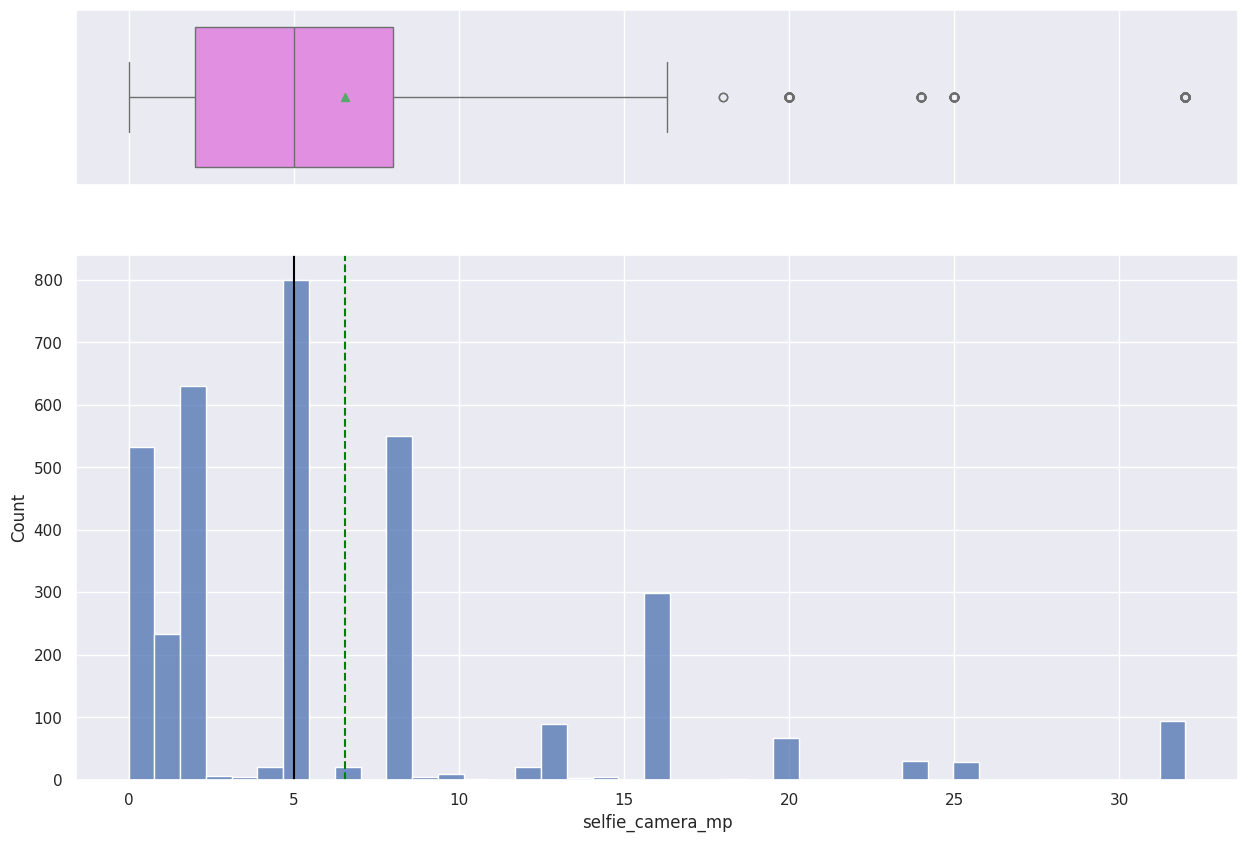

In [36]:
histogram_boxplot(data, "selfie_camera_mp")

**Internal Memory**

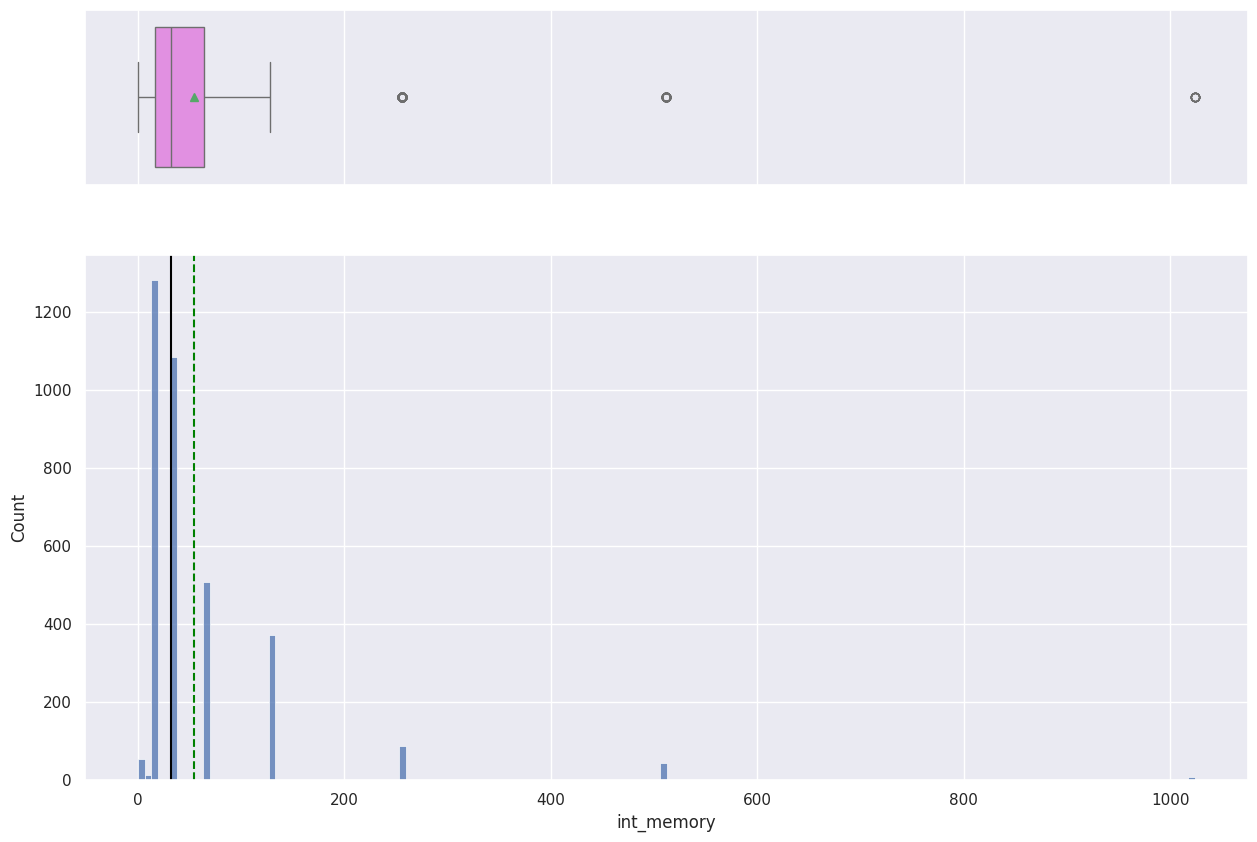

In [37]:
histogram_boxplot(data, "int_memory")

**RAM**

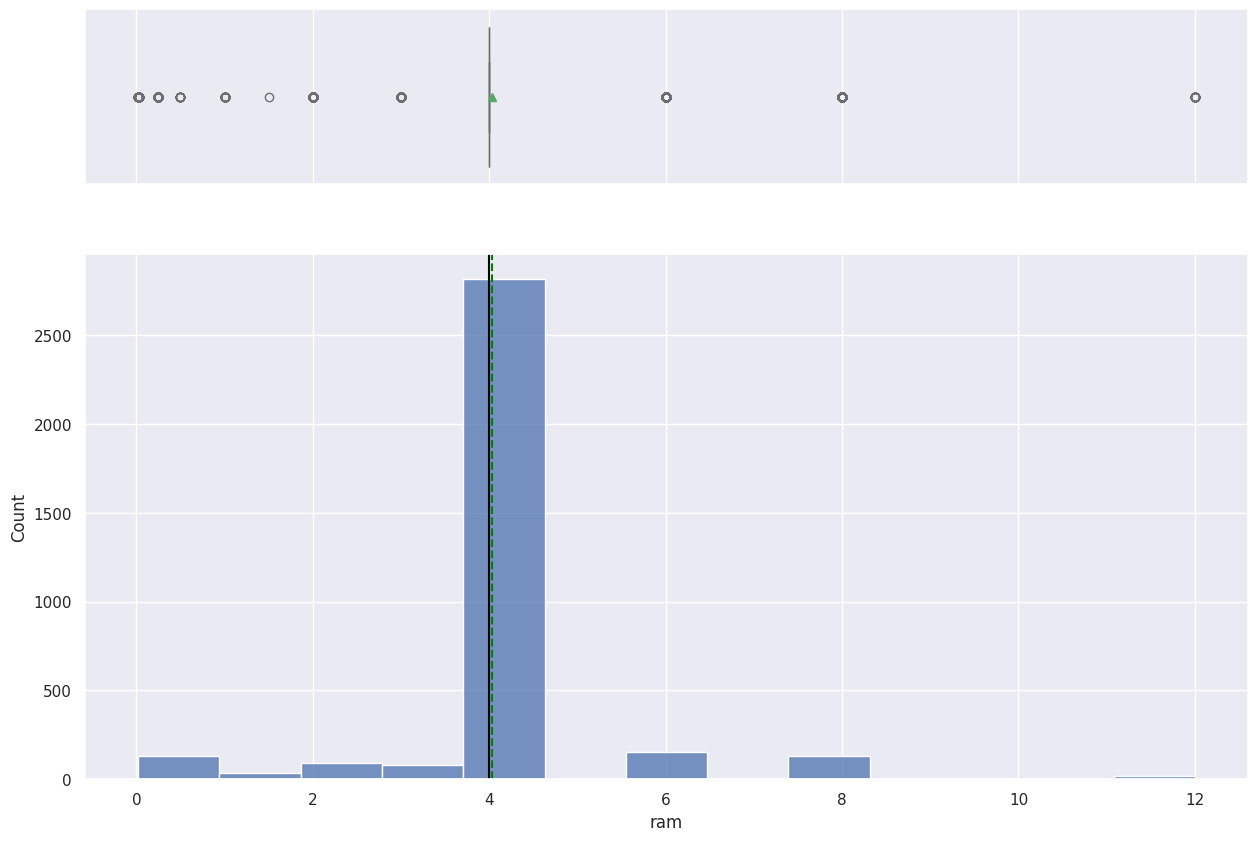

In [38]:
histogram_boxplot(data, "ram")

**Weight**

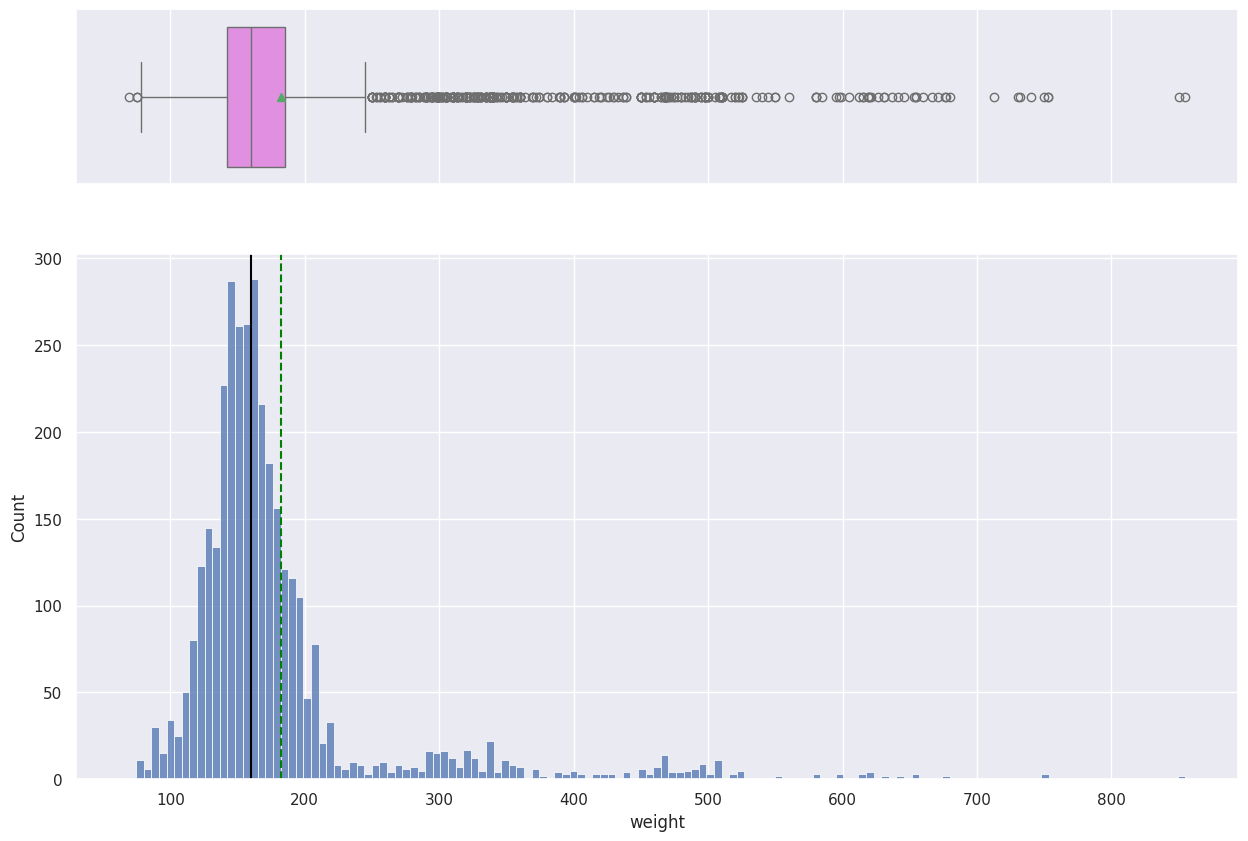

In [39]:
histogram_boxplot(data, "weight")

**Battery**

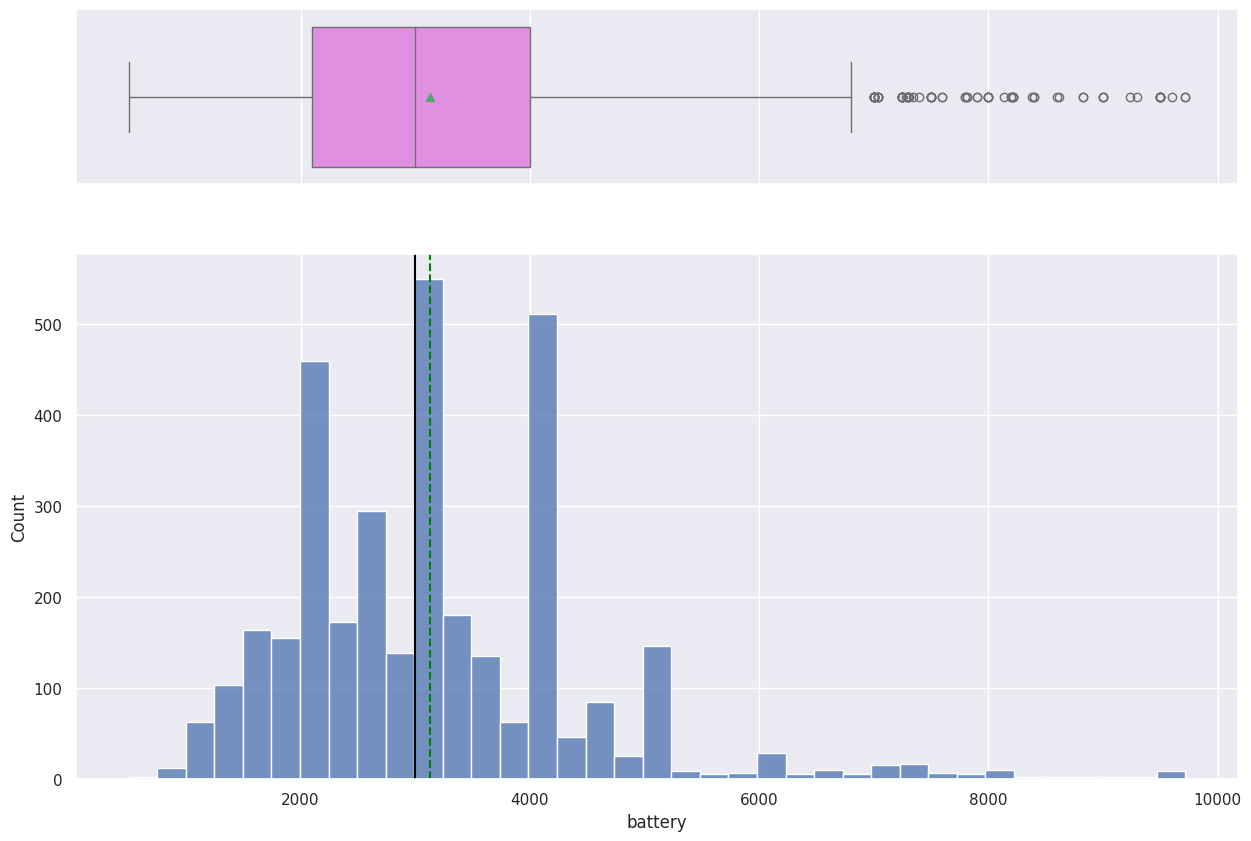

In [40]:
histogram_boxplot(data, "battery")

**Days Used**

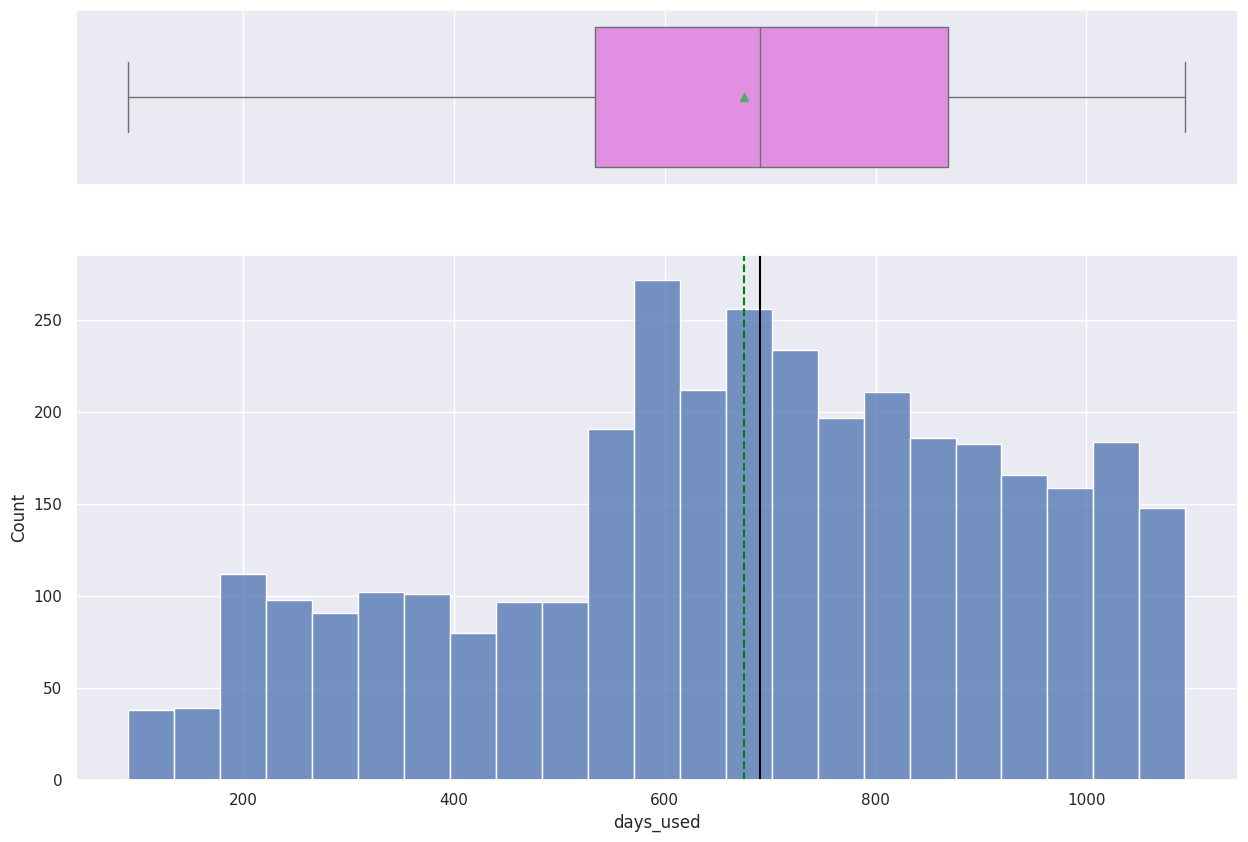

In [41]:
histogram_boxplot(data, "days_used")

**Brand Name**

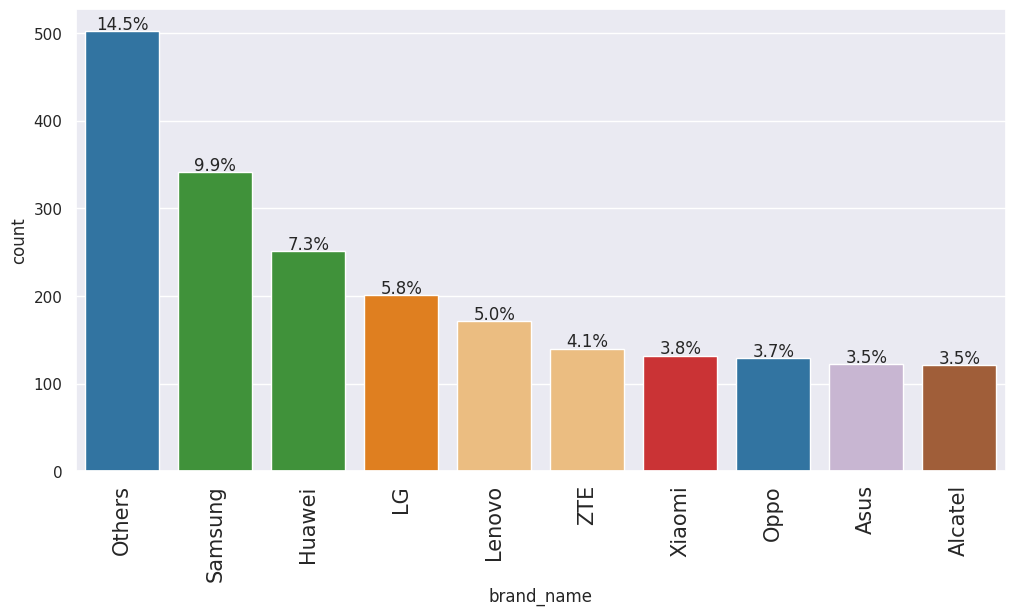

In [42]:
labeled_barplot(data, "brand_name", perc = True, n=10)

**OS**

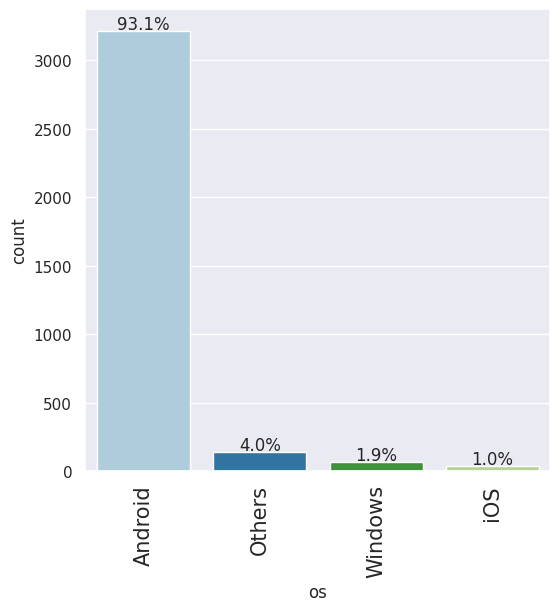

In [43]:
labeled_barplot(data,'os', perc=True)

**4G**

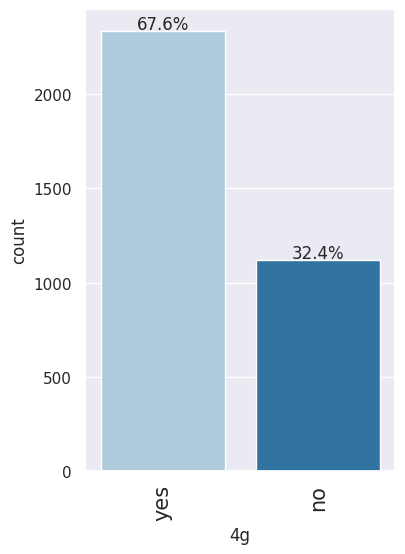

In [44]:
labeled_barplot(data,'4g', perc=True)

**5G**

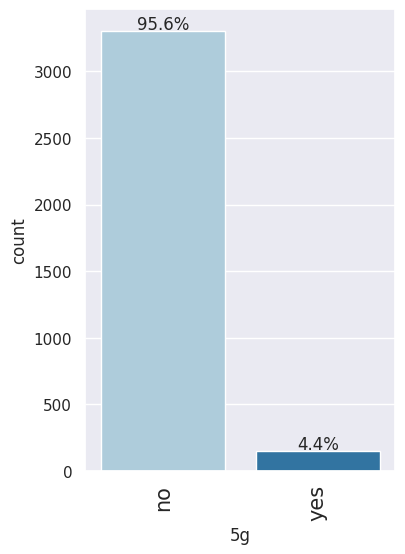

In [45]:
labeled_barplot(data,'5g', perc=True)

**Release_Year**

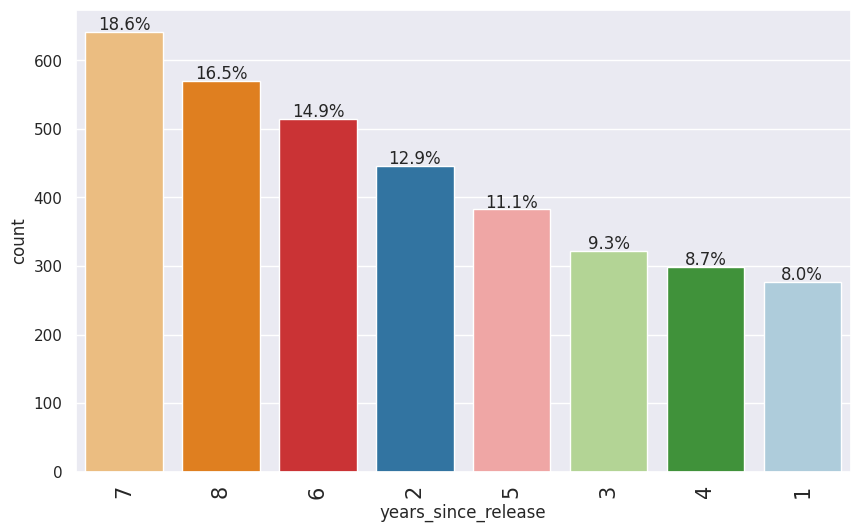

In [46]:
labeled_barplot(data,'years_since_release', perc=True)

##Bivariate Analysis

**Correlation Check**

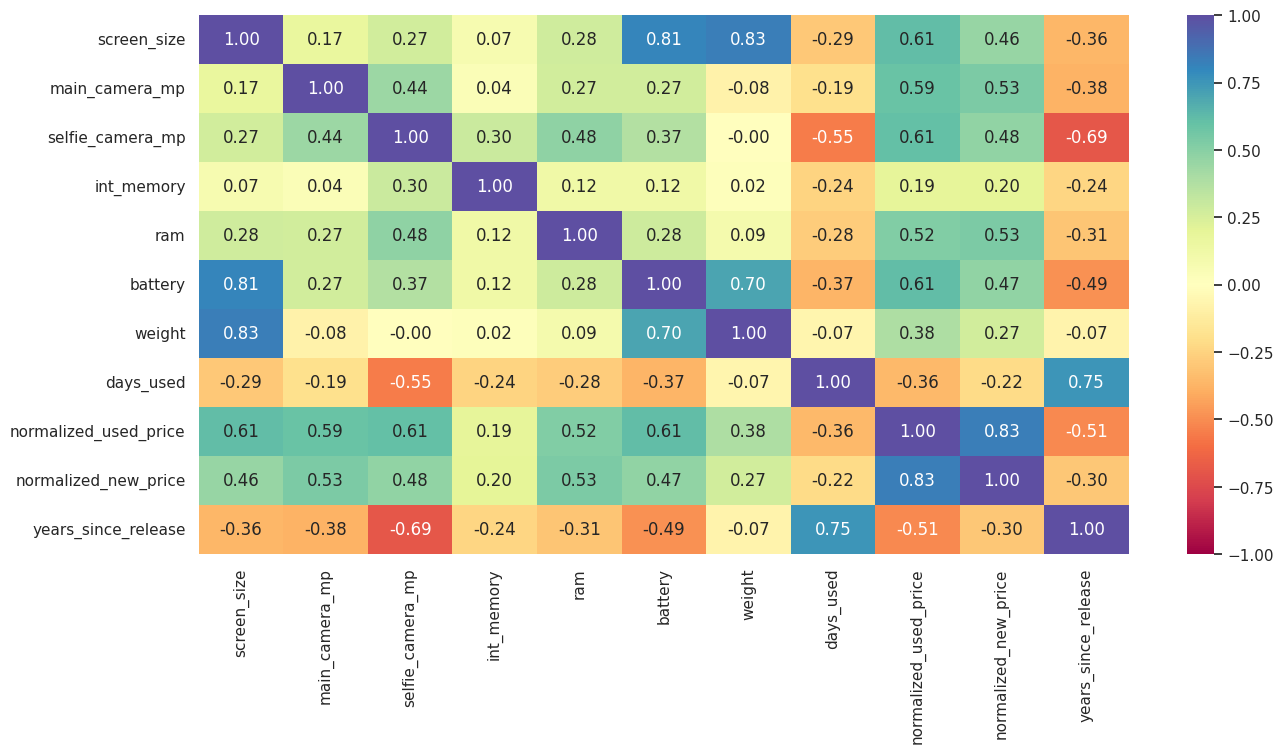

In [47]:
# Create a correlation heat map:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15,7))
sns.heatmap(data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap='Spectral')
plt.show()

Observations:

* Normalized new and used price are heavily correlated, which makes sense.
* Battery and Weight are two factors strongly correlated with screen size, which makes sense as well.


**What percentage of the used device market is dominated by Android devices?**

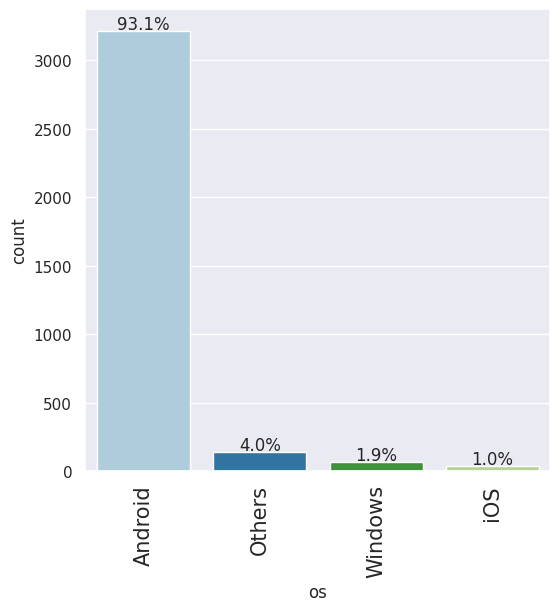

In [48]:
# Create a plot showing what percentage of the used device market is dominated by Android devices:
labeled_barplot(data, 'os', perc=True)

Observation:
* 93% of the used devices market is dominated by Android devices.


**The amount of RAM is important for the smooth functioning of a device. Let's see how the amount of RAM varies across brands.**

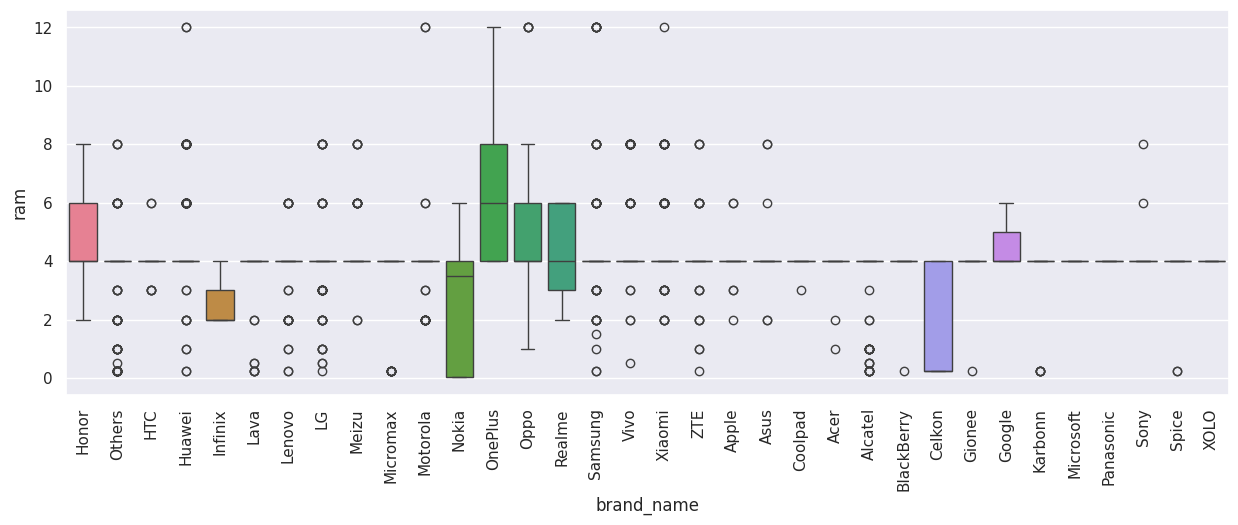

In [49]:
# Create a boxplot outlining relationship between RAM and brand names:
plt.figure(figsize=(15,5))
sns.boxplot(data=data, x='brand_name', y='ram', hue='brand_name')
plt.xticks(rotation=90)
plt.show()

Observation:
* Only a handful of brands carry a RAM larger than 4 GB in at least 75% of their devices: Honor, One Plus, Oppo, and Google.

**People who travel frequently require devices with large batteries to run through the day. But large battery often increases weight, making it feel uncomfortable in the hands. Let's create a new dataframe of only those devices which offer a large battery and analyze.**

In [50]:
# Create a dataframe of devices using a large battery:
df_large_battery = data[data.battery > 4500]
df_large_battery.shape

(341, 15)

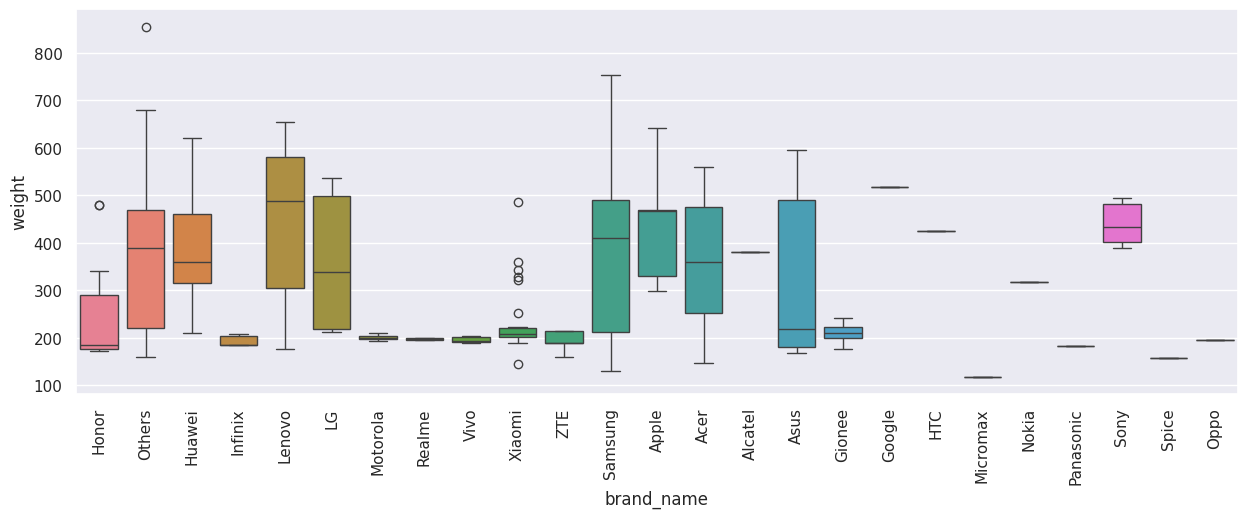

In [51]:
# Create a plot showing the df_large_battery:
plt.figure(figsize=(15,5))
sns.boxplot(data=df_large_battery, x='brand_name', y='weight', hue='brand_name')
plt.xticks(rotation=90)
plt.show()

Observation:
* Devices with large battery capacity and relative low weight are: Honor, Motorola, Realme, Vivo, Xiaomi, ZTE, Gionee, Micromax, Panasonic, Spice and Oppo.

**People who buy phones and tablets primarily for entertainment purposes prefer a large screen as they offer a better viewing experience. Let's create a new dataframe of only those devices which are suitable for such people and analyze.**

In [52]:
# Create a new dataframe of devices with screens larger than 15.34 inches:
df_large_screen = data[data.screen_size > 15.34]
df_large_screen.shape

(861, 15)

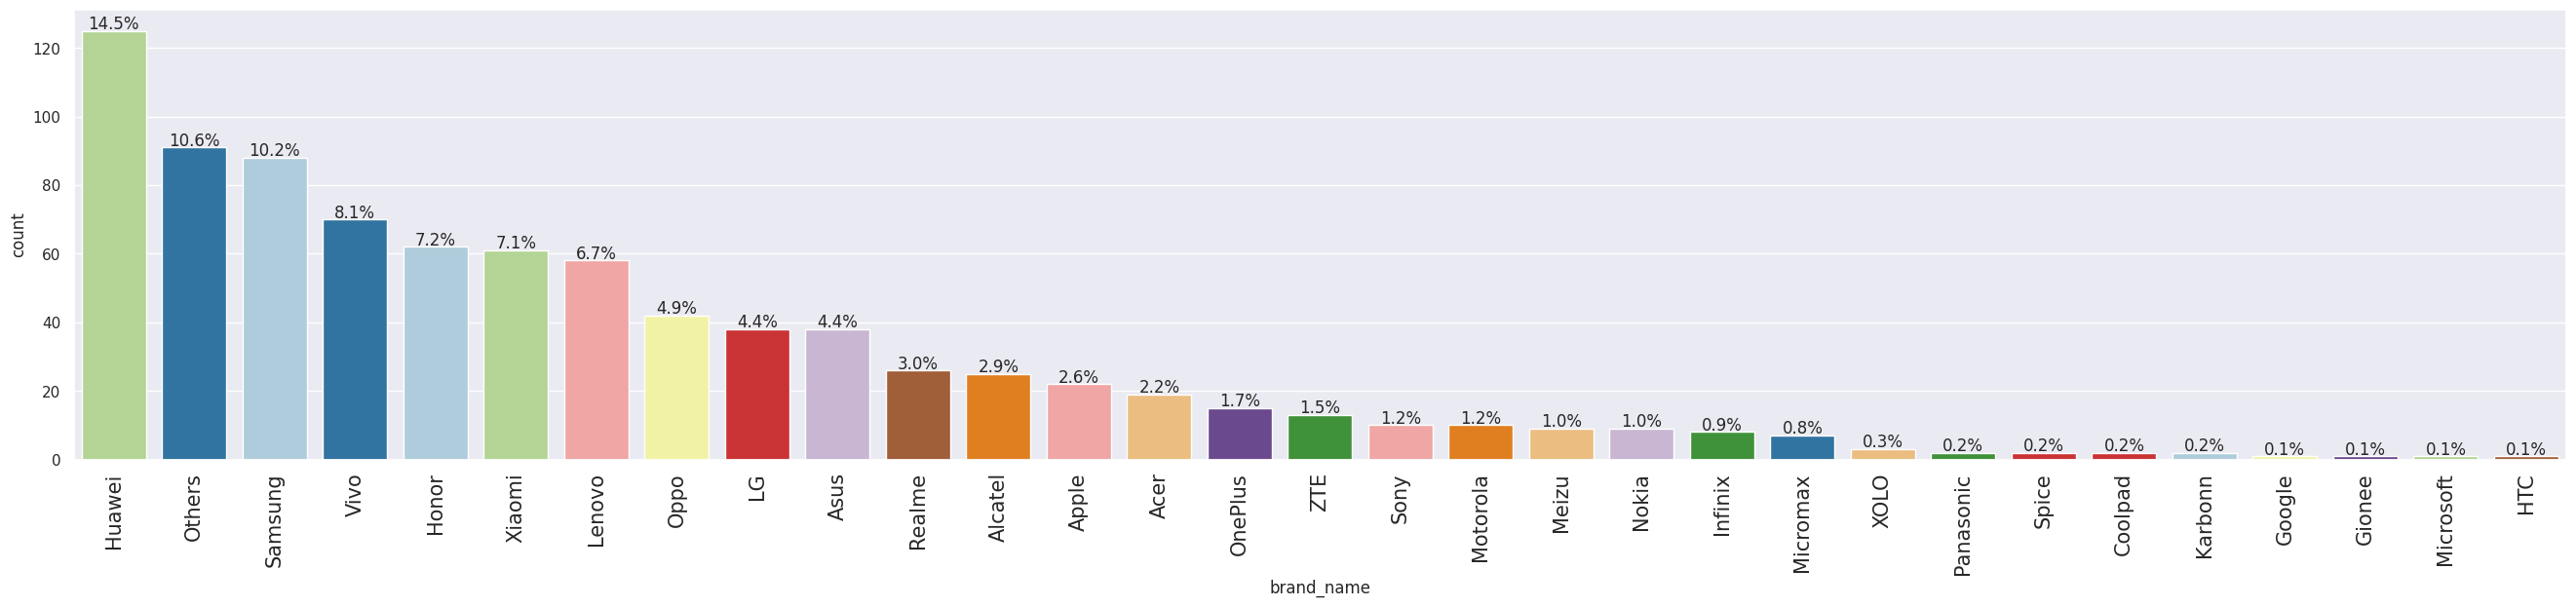

In [53]:
# Create a plot showing large screen devices by brand names:
labeled_barplot(df_large_screen, 'brand_name', perc=True)

Observation:
* Popular large screen devices by brand name are Huawei (14.5%), Others (10.6%), Samsung (10.2%).

**Everyone likes a good camera to capture their favorite moments with loved ones. Some customers specifically look for good front cameras to click cool selfies. Let's create a new dataframe of only those devices which are suitable for this customer segment and analyze.**

In [54]:
# Create a dataframe of devices with highest mega pixels for selfie camera:
df_selfie_camera = data[data.selfie_camera_mp > 8]
df_selfie_camera.shape

(655, 15)

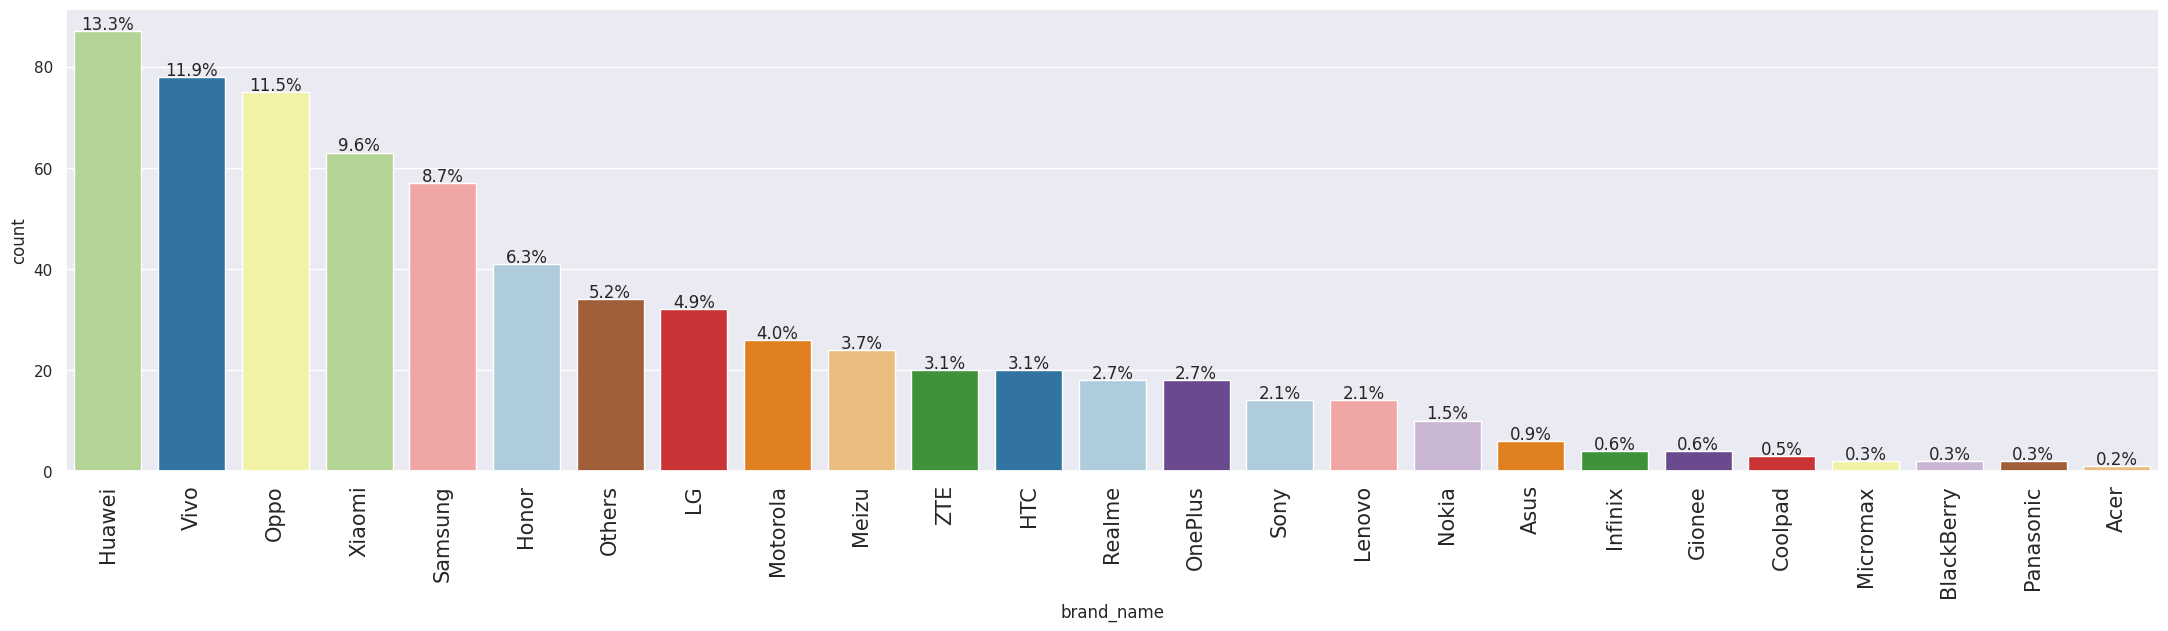

In [55]:
# Create a plot showing which brands have the highest mp in selfie cameras:
labeled_barplot(df_selfie_camera, 'brand_name', perc=True)

Observation:
Selfie cameras with the highest mega pixels are:  Huawei (13.3%), Vivo (11.9%) and Oppo (11.5%)

**Let's do a similar analysis for rear cameras:
* Rear cameras generally have a better resolution than front cameras, so we set the threshold higher for them at 16MP.**

In [56]:
# Create a dataframe for main_camera_mp:
df_main_camera = data[data.main_camera_mp > 16]
df_main_camera.shape

(94, 15)

In [57]:
df_main_camera.head()

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,days_used,normalized_used_price,normalized_new_price,years_since_release
210,ZTE,Android,16.89,yes,no,48.0,16.0,128.0,8.0,5000.0,215.0,336,5.668052,6.708780,2
215,ZTE,Android,16.89,yes,no,48.0,16.0,64.0,6.0,5000.0,215.0,506,5.263726,6.217723,2
428,Acer,Windows,12.83,yes,no,21.0,8.0,32.0,4.0,2870.0,150.0,824,4.590970,5.391216,6
595,Others,Android,15.24,yes,no,24.0,8.0,64.0,4.0,3500.0,204.4,924,5.053439,6.190684,6
686,Others,Android,12.83,yes,no,20.7,8.0,64.0,4.0,2950.0,193.0,608,4.824225,5.519940,5


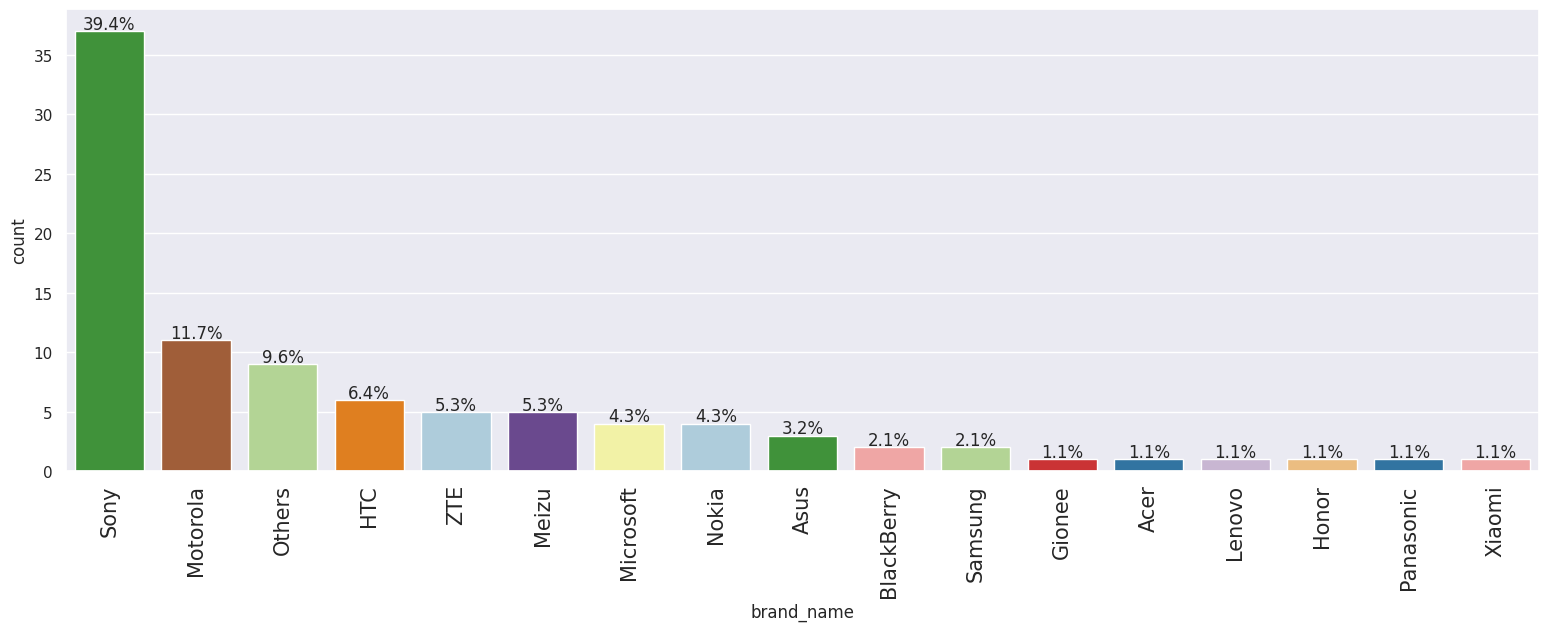

In [58]:
# Create a labeled barplot:
labeled_barplot(df_main_camera, 'brand_name', perc=True)

Observation:
* Main camera with the highest mp are Sony (39.4%), Motorola (11.7%), and others (9.6%)

**Let's see how the price of used devices varies across the years:**

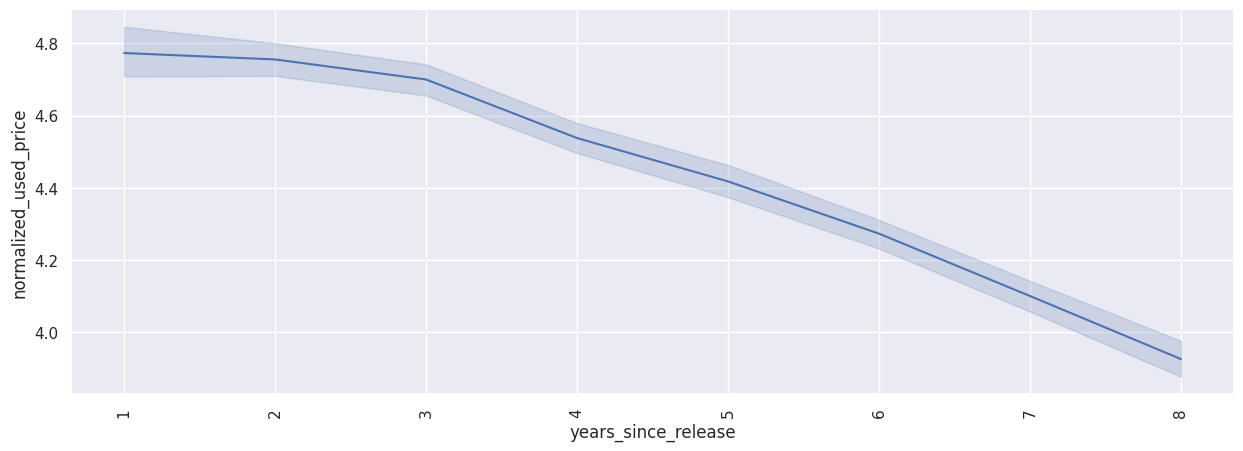

In [59]:
# Create a lineplot showing how the price of used devices varies over the years:
plt.figure(figsize=(15,5))
sns.lineplot(data=data, x='years_since_release', y='normalized_used_price')
plt.xticks(rotation=90)
plt.show()

Observation:
* Price for used devices slowly decline up until 3 years after release, but devalue at a faster clip after 3 years and beyond.

* Price for used devices has been going up steadily from 2013 to 2018, after which the price increase rate slows down a bit until 2020, the latest year for which we have data.

**Let's check how the prices vary for used phones and tablets offering 4G and 5G networks:**

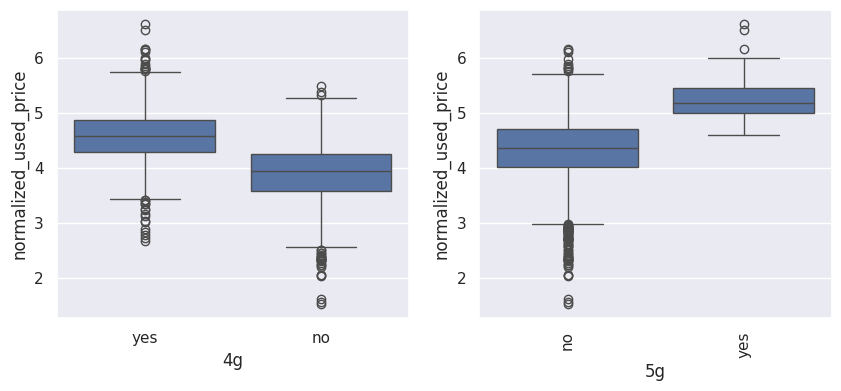

In [60]:
# Create a plot showing how prices vary for used devices offering 4G and 5G networks:
plt.figure(figsize=(10,4))

plt.subplot(121)
sns.boxplot(data=data, x='4g', y='normalized_used_price')

plt.subplot(122)
sns.boxplot(data=data, x='5g', y='normalized_used_price')

plt.xticks(rotation=90)
plt.show()

Observation:

The price for used devices is higher for devices offering 4G and 5G networks.

### Data Preparation for modeling


-We want to predict the normalized price of used devices

-Before we proceed to build a model, we'll have to encode categorical features

-We will split the data into train and test to be able to evaluate the model that we build on the train data

-We will build a Linear Regression model using the train data and then check it's performance

In [61]:
# Define the dependent and independent variables:
X = data.drop(['normalized_used_price'], axis=1)
y = data['normalized_used_price']

print(X.shape)
print(y.shape)

(3454, 14)
(3454,)


In [62]:
# Let's add the intercept to data:
X = sm.add_constant(X)  #sm stands for statsmodels


In [63]:
# Create dummy variables for independent features:
X = pd.get_dummies(X, columns = X.select_dtypes(include=['object', 'category']).columns.tolist(), drop_first=True) # drop_first=True is added to avoid multicollinearity.

# Drop the original categorical columns, in order to run a linear regression model:
X = X.select_dtypes(exclude=['object', 'category'])

X.head()

,const,screen_size,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,days_used,normalized_new_price,...,brand_name_Spice,brand_name_Vivo,brand_name_XOLO,brand_name_Xiaomi,brand_name_ZTE,os_Others,os_Windows,os_iOS,4g_yes,5g_yes
0,1.0,14.50,13.0,5.0,64.0,3.0,3020.0,146.0,127,4.715100,...,False,False,False,False,False,False,False,False,True,False
1,1.0,17.30,13.0,16.0,128.0,8.0,4300.0,213.0,325,5.519018,...,False,False,False,False,False,False,False,False,True,True
2,1.0,16.69,13.0,8.0,128.0,8.0,4200.0,213.0,162,5.884631,...,False,False,False,False,False,False,False,False,True,True
3,1.0,25.50,13.0,8.0,64.0,6.0,7250.0,480.0,345,5.630961,...,False,False,False,False,False,False,False,False,True,True
4,1.0,15.32,13.0,8.0,64.0,3.0,5000.0,185.0,293,4.947837,...,False,False,False,False,False,False,False,False,True,False


In [64]:
# Split the data in 70:30 ratio for train and test sets:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [65]:
print("number of rows in training data=", X_train.shape[0])
print("number of columns in test data=", X_test.shape[1])

number of rows in training data= 2417
number of columns in test data= 49


## Model Building - Linear Regression

In [66]:
# Build a linear regression model using the training data:

# Check for missing values in training data before fitting the model
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in y_train:", y_train.isnull().sum())

# Check data types of X_train
print("Data types of X_train:\n", X_train.dtypes)

# Convert X_train to float64 to ensure all columns are numeric
X_train = X_train.astype(np.float64)

model = sm.OLS(y_train, X_train).fit()
print(model.summary())

Missing values in X_train: 0
Missing values in y_train: 0
Data types of X_train:
 const                    float64
screen_size              float64
main_camera_mp           float64
selfie_camera_mp         float64
int_memory               float64
ram                      float64
battery                  float64
weight                   float64
days_used                  int64
normalized_new_price     float64
years_since_release        int64
brand_name_Alcatel          bool
brand_name_Apple            bool
brand_name_Asus             bool
brand_name_BlackBerry       bool
brand_name_Celkon           bool
brand_name_Coolpad          bool
brand_name_Gionee           bool
brand_name_Google           bool
brand_name_HTC              bool
brand_name_Honor            bool
brand_name_Huawei           bool
brand_name_Infinix          bool
brand_name_Karbonn          bool
brand_name_LG               bool
brand_name_Lava             bool
brand_name_Lenovo           bool
brand_name_Meizu           

Interpreting the regression results:

- Adjusted R Squared: reflects the fit of the model, with values generally ranging between 0 and 1.  A higher value generally indicates a better fit, assuming certain conditions are met.  In our case the value is 0.849 which is good.

- Constant Coefficient: reflects the Y-intercept. It means that if all the predictor variable coefficients are zero, then the expected output (i.e., Y) would be equal to the const coefficient. In our case, the value for const coefficient is 1.4172.

- Coefficient of a predictor variable: represents the change in the output Y due to a change in the predictor variable (everything else held constant). In our case, the coefficient of screen_size is 0.0295.

## Model Performance Check

**Let's check the performance of the model using different metrics.**

* We will be using metric functions defined in sklearn for RMSE (root mean squared error), MAE, and $R^2$.
* We will define a function to calculate MAPE (mean absolute percentage error) and adjusted $R^2$.    
* We will create a function which will print out all the above metrics in one go.

In [67]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mape_score(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

In [68]:
# Checking model performance on train set (seen 70% data)
print("Model Training Performance \n")
model_train_performance = model_performance_regression(model, X_train, y_train)
model_train_performance

Model Training Performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.229761,0.178533,0.848887,0.845758,4.293664


In [69]:
# Checking model performance on test set (30% of data):
print("Model Testing Performance \n")
model_test_performance = model_performance_regression(model, X_test, y_test)
model_test_performance

Model Testing Performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.239062,0.188692,0.832176,0.823844,4.513288


Observation:

- The training R2 value is 0.84, which is a decent score and the model is not underfitting.

- The train and test RMSE and MAE values are similar, which means the model is not overfitting either.

- RMSE quantifies how spread out the residuals (the difference between predicted and actual values) are around the regression line.

- MAE suggests that the model can predict the normalized_used_price within a mean error of 0.188 on the test data.  

- MAPE of 4.5 on the test data means that we are able to predict within 4.5% of the normalized_used_price.



## Checking Linear Regression Assumptions

- In order to make statistical inferences from a linear regression model, it is important to ensure that the assumptions of linear regression are satisfied.

We will be checking the following Linear Regression assumptions:

1. **No Multicollinearity**

2. **Linearity of variables**

3. **Independence of error terms**

4. **Normality of error terms**

5. **No Heteroscedasticity**

### TEST FOR MULTICOLLINEARITY


- We will test for multicollinearity using VIF.

- **General Rule of thumb**:
    - If VIF is 1 then there is no correlation between the predictor and the remaining predictor variables.
    - If VIF exceeds 5 or is close to exceeding 5, we say there is moderate multicollinearity.
    - If VIF is 10 or exceeding 10, it shows signs of high multicollinearity.

In [70]:
# Define a function to check VIF:
def check_vif(predictors):
    vif= pd.DataFrame()
    vif['Predictors'] = predictors.columns
    vif['VIF'] = [variance_inflation_factor(predictors.values, i) for i in range (len(predictors.columns))]
    return(vif)


In [71]:
check_vif(X_train)

,Predictors,VIF
0,const,232.676933
1,screen_size,8.262147
2,main_camera_mp,2.420116
3,selfie_camera_mp,2.872720
4,int_memory,1.363390
5,ram,2.283507
6,battery,4.066126
7,weight,6.417982
8,days_used,2.580338
9,normalized_new_price,3.218722


Observations:

Columns with a VIF score greater than 5: screen size, and weight.

To be ignored:  the constant and dummy variables (categorical columns).

### Removing Multicollinearity (if needed)


To remove multicollinearity:

1. Drop every column one by one that has a VIF score greater than 5.
2. Look at the adjusted R-squared and RMSE of all these models.
3. Drop the variable that makes the least change in adjusted R-squared.
4. Check the VIF scores again.
5. Continue till you get all VIF scores under 5.

Let's define a function that will help us do this.

In [72]:
def treating_multicollinearity(predictors, target, high_vif_columns):
    """
    Checking the effect of dropping the columns showing high multicollinearity
    on model performance (adj. R-squared and RMSE)

    predictors: independent variables
    target: dependent variable
    high_vif_columns: columns having high VIF
    """
    # empty lists to store adj. R-squared and RMSE values
    adj_r2 = []
    rmse = []

    # build ols (ordinary least squares) models by dropping one of the high VIF columns at a time
    # store the adjusted R-squared and RMSE in the lists defined previously
    for cols in high_vif_columns:
        # defining the new train set
        train = predictors.loc[:, ~predictors.columns.str.startswith(cols)]

        # create the model, using statsmodel package
        olsmodel = sm.OLS(target, train).fit()

        # adding adj. R-squared and RMSE to the lists
        adj_r2.append(olsmodel.rsquared_adj)
        rmse.append(np.sqrt(olsmodel.mse_resid))

    # creating a dataframe for the results
    temp = pd.DataFrame(
        {
            "col": high_vif_columns,
            "Adj. R-squared after_dropping col": adj_r2,
            "RMSE after dropping col": rmse,
        }
    ).sort_values(by="Adj. R-squared after_dropping col", ascending=False)
    temp.reset_index(drop=True, inplace=True)

    return temp

In [73]:
# Specify the columns with high VIF (variance inflation factor):
high_vif_columns = ['screen_size', 'weight', 'os_iOS']

In [74]:
# Check the effect on model performance after dropping high VIF columns from training data:
treating_multicollinearity(X_train, y_train, high_vif_columns)

,col,Adj. R-squared after_dropping col,RMSE after dropping col
0,os_iOS,0.845888,0.232077
1,weight,0.843587,0.233803
2,screen_size,0.841348,0.235470


Observation: adj_r2 and RMSE after dropping high VIF columns don't seem to change that much compared to including them.

In [75]:
# Specify the highest VIF column to drop first:
col_to_drop = 'os_iOS'

# Specify the train and test data from which to drop 'os_iOS':
X_train2 = X_train.loc[:, ~X_train.columns.str.startswith(col_to_drop)]
X_test2 = X_test.loc[:, ~X_test.columns.str.startswith(col_to_drop)]

# Check VIF now:
vif = check_vif(X_train2)
print('VIF after dropping column', col_to_drop)
vif


VIF after dropping column os_iOS


,Predictors,VIF
0,const,231.265323
1,screen_size,8.175755
2,main_camera_mp,2.417436
3,selfie_camera_mp,2.860115
4,int_memory,1.363372
5,ram,2.267806
6,battery,4.061755
7,weight,6.392276
8,days_used,2.579961
9,normalized_new_price,3.218565


In [76]:
# Specify the columns with remaining high VIF:
high_vif_columns = ['screen_size', 'weight']

# Check the effect on model performance after dropping specfied columns from training data:
treating_multicollinearity(X_train2, y_train, high_vif_columns)

,col,Adj. R-squared after_dropping col,RMSE after dropping col
0,weight,0.843648,0.233758
1,screen_size,0.841356,0.235465


 Observation: Above DataFrame contains the Adjusted R-squared and RMSE values when each of the specified high-VIF columns is individually dropped. This helps in deciding which column to drop next to reduce multicollinearity while minimizing the impact on the model's performance.

In [77]:
col_to_drop = 'weight'
X_train3 = X_train2.loc[:, ~X_train2.columns.str.startswith(col_to_drop)]
X_test3 = X_test2.loc[:, ~X_test2.columns.str.startswith(col_to_drop)]

# Check VIF now:
vif = check_vif(X_train3)
print('VIF after dropping column', col_to_drop)
vif

VIF after dropping column weight


,Predictors,VIF
0,const,216.486079
1,screen_size,3.661817
2,main_camera_mp,2.335755
3,selfie_camera_mp,2.830508
4,int_memory,1.363326
5,ram,2.263148
6,battery,3.767113
7,days_used,2.562694
8,normalized_new_price,3.217237
9,years_since_release,4.748897


Observation:  No more high VIF columns (note that the constant and dummy variables in principle do not show correlation).

In [78]:
# We have dealt with the multicollinearity in the data.
# Let's rebuild the model using the updated set of predictor variables:
model2 = sm.OLS(y_train, X_train3).fit()
print(model2.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.847
Model:                               OLS   Adj. R-squared:                  0.844
Method:                    Least Squares   F-statistic:                     284.4
Date:                   Mon, 08 Sep 2025   Prob (F-statistic):               0.00
Time:                           05:58:23   Log-Likelihood:                 107.20
No. Observations:                   2417   AIC:                            -120.4
Df Residuals:                       2370   BIC:                             151.8
Df Model:                             46                                         
Covariance Type:               nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------


Observation on new model after addressing multicollinearity:

-The adjusted R squared value dropped from 0.849 in the original model to 0.844 in the new model, a very minimal change.  The dropped predictor variables with high multicollinearity had little effect on the original model.

-Now that mulitcollinearity has been addressed, we can look at the p-values of remaining predictor variables to check their significance.

### Dropping high p-value variables (if needed)

- We will drop the predictor variables having a p-value greater than 0.05 as they do not significantly impact the target variable.
- But sometimes p-values change after dropping a variable. So, we'll not drop all variables at once.
- Instead, we will do the following:
    - Build a model, check the p-values of the variables, and drop the column with the highest p-value.
    - Create a new model without the dropped feature, check the p-values of the variables, and drop the column with the highest p-value.
    - Repeat the above two steps till there are no columns with p-value > 0.05.

The above process can also be done manually by picking one variable at a time that has a high p-value, dropping it, and building a model again. But that might be a little tedious and using a loop will be more efficient.

In [79]:
# Initial list of columns:
predictors = X_train3.copy()
cols = predictors.columns.tolist()

# Setting an initial max p-value:
max_p_value = 1

while len(cols) > 0:
    # defining the train set:
    x_train_aux = predictors[cols]

    # fitting the model:
    model = sm.OLS(y_train, x_train_aux).fit()

    # getting the p-values and the maximum p-value:
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value:
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
        print(f"DROPPED: feature: {feature_with_p_max} with_p-value {max_p_value}")
    else:
        break

selected_features = cols
print(f"Selected features: {selected_features}")

DROPPED: feature: brand_name_Infinix with_p-value 0.9849490343128664
DROPPED: feature: brand_name_Asus with_p-value 0.975923534603325
DROPPED: feature: os_Others with_p-value 0.7634697108116653
DROPPED: feature: brand_name_BlackBerry with_p-value 0.7556944934141484
DROPPED: feature: brand_name_Spice with_p-value 0.6142364975852992
DROPPED: feature: brand_name_Gionee with_p-value 0.6359199778330582
DROPPED: feature: brand_name_Coolpad with_p-value 0.5797450576254539
DROPPED: feature: brand_name_Lava with_p-value 0.5124663050543268
DROPPED: feature: battery with_p-value 0.4676519568721813
DROPPED: feature: brand_name_OnePlus with_p-value 0.4679788069749954
DROPPED: feature: brand_name_Apple with_p-value 0.46971262087947363
DROPPED: feature: brand_name_Realme with_p-value 0.47877214513402266
DROPPED: feature: brand_name_Oppo with_p-value 0.5226042230614805
DROPPED: feature: brand_name_Panasonic with_p-value 0.49807115425020065
DROPPED: feature: brand_name_Lenovo with_p-value 0.52675510368

In [80]:
# Specify the training data from the selected features with p-values < 0.05
# low p-value of < 0.05 indicates a statistically significant relationship between dependent variable and predictors).

X_train4 = X_train3[selected_features]
X_test4 = X_test3[selected_features]

## Model 3 with updated dataset with no multicollinearity and no insignificant predictors.

In [81]:
# Create model 3 with updated dataset that has no multicollinearity and no insignificant predictors:
Model3 = sm.OLS(y_train, X_train4).fit()
print(Model3.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.845
Model:                               OLS   Adj. R-squared:                  0.844
Method:                    Least Squares   F-statistic:                     1090.
Date:                   Mon, 08 Sep 2025   Prob (F-statistic):               0.00
Time:                           05:58:23   Log-Likelihood:                 92.730
No. Observations:                   2417   AIC:                            -159.5
Df Residuals:                       2404   BIC:                            -84.19
Df Model:                             12                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

In [82]:
# Checking model 3 performance on train set:
print("Model 3 Training Performance \n")
model_train_performance = model_performance_regression(Model3, X_train4, y_train)
model_train_performance

Model 3 Training Performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.232863,0.180656,0.844778,0.843938,4.348441


In [83]:
# Checking model performance on test set:
print("Model 3 Testing Performance \n")
model_test_performance = model_performance_regression(Model3, X_test4, y_test)
model_test_performance

Model 3 Testing Performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.241711,0.191096,0.828436,0.826256,4.568682


Observations:

- We eliminated multicollinearity and we eliminated statistically insignificant features.

- Based on the remaining selected features that indicate a statistically signifcant relationship to the predictor variable, we built a final model.  

- The metrics of this final model shows the adjusted R squared of 0.826, which means our model is able to explain ~82% of the variance.

- The adjusted R squared in the first model was 0.823, which means the variables we dropped to eliminate multicollinearity were not affecting the model much.

- The RMSE (mean squared error) and MAE (Mean Absolute Error) are comparable in the final training and test sets, indicating that the model is not overfitting.

**Now we'll check the rest of the assumptions on the Final Model.**
1. **No multicollinearity** - checked

2. **Linearity of variables**

3. **Independence of error terms**

4. **Normality of error terms**

5. **No Heteroscedasticity**

### TEST FOR LINEARITY AND INDEPENDENCE

- We will test for linearity and independence by making a plot of fitted values vs residuals and checking for patterns.
- If there is no pattern, then we say the model is linear and residuals are independent.
- Otherwise, the model is showing signs of non-linearity and residuals are not independent.


In [84]:
# Create a dataframe with actual, fitted and residual values:
df_pred = pd.DataFrame()
df_pred['actual'] = y_train
df_pred['fitted'] = Model3.fittedvalues
df_pred['residuals'] = Model3.resid

df_pred.head()

,actual,fitted,residuals
1744,4.261975,4.307119,-0.045143
3141,4.175156,3.817346,0.357811
1233,4.117410,4.439774,-0.322364
3046,3.782597,3.839703,-0.057105
2649,3.981922,3.934233,0.047690


**Residuals as Errors:**

The residuals are the differences between the observed (actual) values of the dependent variable and the values predicted by the linear model. These residuals represent the part of the dependent variable that the linear model could not explain. They are considered the "errors" of the model.

**Assumption about Residuals (Errors):**

The linearity assumption manifests in the behavior of the residuals. If the linear model is appropriate and the relationship is truly linear, the residuals should be random and unstructured.



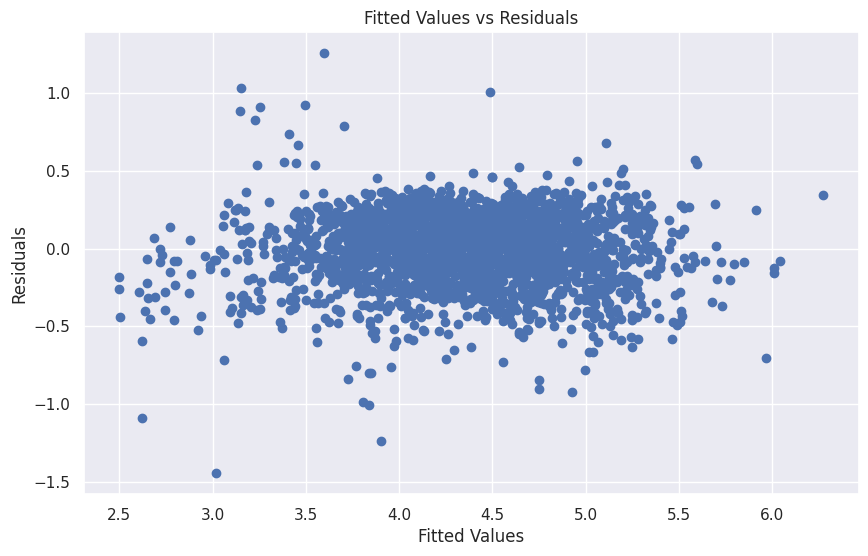

In [85]:
# Let's plot the fitted values vs residuals:
plt.figure(figsize=(10, 6))
plt.scatter(df_pred['fitted'], df_pred['residuals'])
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Fitted Values vs Residuals')
plt.show()

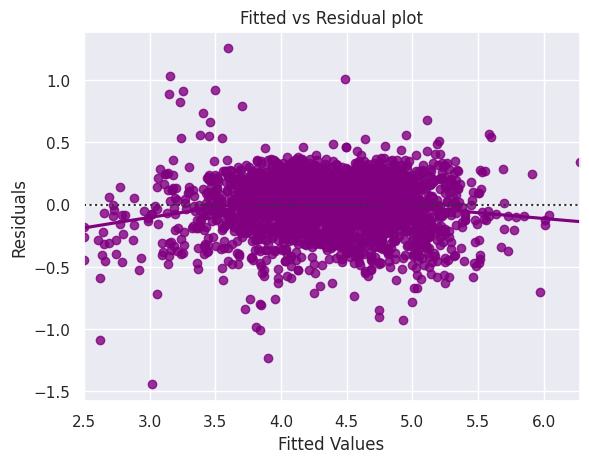

In [86]:
sns.residplot(
    data=df_pred, x="fitted", y="residuals", color="purple", lowess=True
)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted vs Residual plot")
plt.show()

Observation:

Looking at the plot, the LOWESS line does appear to have a slight curve, suggesting that the linearity assumption might not be perfectly met.

However, overall the residuals appear as a random cloud scattered around the horizontal line at zero.  The LOWESS line is relatively flat and close to zero.

We see no pattern in the plot above, hence the assumptions of linearity and independence of error terms are satisfied.

### TEST FOR NORMALITY

- We will test for normality by checking the distribution of residuals, by checking the Q-Q plot of residuals, and by using the Shapiro-Wilk test.
- If the residuals follow a normal distribution, they will make a straight line plot, otherwise not.
- If the p-value of the Shapiro-Wilk test is greater than 0.05, we can say the residuals are normally distributed.

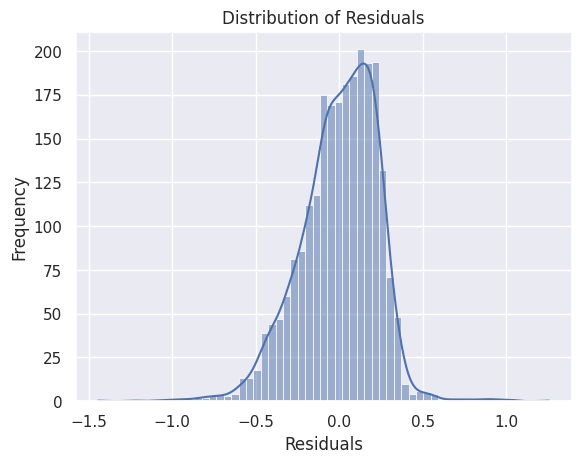

In [87]:
# Plot the distribution of residuals:
sns.histplot(df_pred['residuals'], kde=True)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()


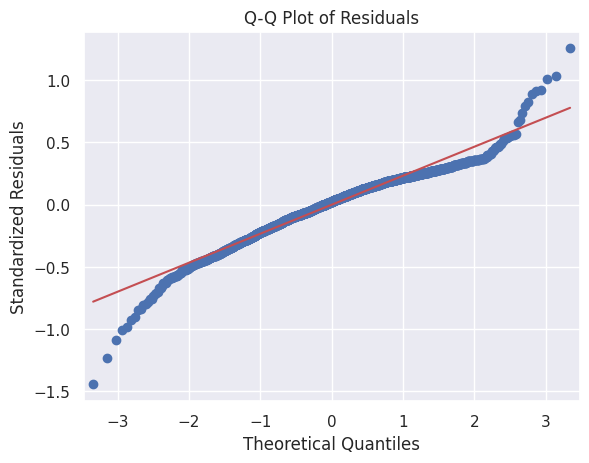

In [88]:
# Check the Q-Q plot of residuals to test normality of error terms:
sm.qqplot(df_pred['residuals'], line='s')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Standardized Residuals')
plt.title('Q-Q Plot of Residuals')
plt.show()

Observation:   The residuals more or less follow a straight line except for the tails.


In [89]:
# Apply the Shapiro-Wilk test for normality:
from scipy.stats import shapiro
shapiro(df_pred['residuals'])



ShapiroResult(statistic=np.float64(0.9657551786354808), pvalue=np.float64(1.5795405365115836e-23))

Observation:

The number 1.5795405365115836e-23 is written in scientific notation. The "e-23" means that you move the decimal point 23 places to the left.

This results in a very, very small number:

0.000000000000000000000015795...

This number is significantly smaller than the p-value threshold of 0.05.

Since p-value < 0.05, the residuals are not normal as per the Shapiro-Wilk test. Strictly speaking, the residuals are not normal. However, as an approximation, we can accept this distribution as close to being normal. So, the assumption is satisfied.

Usually, if the QQPLOT follows very closely the diagonal line in the theoretical quantile range [-2, 2], the assumption is reasonably satisfied.

### TEST FOR HOMOSCEDASTICITY

- We use the Goldfeld-Quandt test to assess the assumption of homoscedasticity in our model's residuals.

- The null hypothesis for the Goldfeld-Quandt test is that the residuals are homoscedastic (constant variance).  The alternative hypothesis is that the residuals are heteroscedastic (non-constant variance).

- If the p-value from the Goldfeld-Quandt test is >0.05, you fail to reject the null hypothesis of homoscedasticity. This means there is no significant evidence to suggest that the residuals have unequal variances across the range of fitted values, and the assumption of homoscedasticity is met.    

In [90]:
# Apply the Goldfeldquandt test using the correct training data:
from statsmodels.stats.diagnostic import het_goldfeldquandt
test = het_goldfeldquandt(df_pred['residuals'], Model3.model.exog)

# Determine the test statistic (F-statistic) from the Goldfeld-Quandt test:
print("Test statistic is:", test[0])


Test statistic is: 0.9272096914925969


The F-statistic, or test statistic in the Goldfeld-Quandt test determines whether the variance of the residuals is constant across different parts of the data.  

A F-statistic close to 1 suggests that the variances of the residuals are roughly equal, and supports the null hypothesis of homoscedasticity (constant variance).

In [91]:
# Determine the p-value from the Goldfeld-Quandt test:
print("P-value associated with the F-statistic is:", test[1])

P-value associated with the F-statistic is: 0.9042418044290996


The p-value from this Goldfeld-Quandt test is greater than 0.05, therefore we fail to reject the null hypothesis of homoscedasticity.  There is no significant evidence to suggest that the residuals have unequal variances across the range of fitted values, and the assumption of homoscedasticity is met.

In [92]:
# Predictions on the test set:
y_pred = Model3.predict(X_test4)

df_pred_test = pd.DataFrame()
df_pred_test['actual'] = y_test
df_pred_test['predicted']= y_pred
df_pred_test['residuals']= df_pred_test['actual'] - df_pred_test['predicted']
df_pred_test.head()

,actual,predicted,residuals
511,3.974246,3.907089,0.067157
51,5.001191,4.942263,0.058928
1171,4.562054,4.293724,0.26833
2282,4.176232,4.040319,0.135913
557,3.156149,3.80975,-0.653601


## Final Model Summary

In [93]:
# Fit the final model:
X_train_final = X_train4
X_test_final = X_test4
model_final = sm.OLS(y_train, X_train_final).fit()
print(model_final.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.845
Model:                               OLS   Adj. R-squared:                  0.844
Method:                    Least Squares   F-statistic:                     1090.
Date:                   Mon, 08 Sep 2025   Prob (F-statistic):               0.00
Time:                           05:58:25   Log-Likelihood:                 92.730
No. Observations:                   2417   AIC:                            -159.5
Df Residuals:                       2404   BIC:                            -84.19
Df Model:                             12                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

In [94]:
# Check model performance on train set (seen 70% data)
print("Training Performance\n")
model_final_train_perf = model_performance_regression(model_final, X_train_final, y_train)
model_final_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.232863,0.180656,0.844778,0.843938,4.348441


In [95]:
# Check model performance on test set (seen 30% data)
print("Test Performance\n")
model_final_test_perf = model_performance_regression(model_final, X_test_final, y_test)
model_final_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.241711,0.191096,0.828436,0.826256,4.568682


## Actionable Insights and Recommendations

The R-squared metric tells us the final model is able to predict ~82% of the data.  

The train and test RMSE and MAE are low and comparable. This means our model is not suffering from overfitting

The MAPE on the test set suggests we can predict within 4.5% error margin the predictor variable.  

Hence, we can conclude the model is good for prediction as well as inference purposes.